# Alzheimer's Disease Diagnosis — Data Exploration & Modeling

In [2]:
import numpy as np
import pandas as pd

## 1. Load Data

In [3]:
df = pd.read_csv("alzheimers_disease_data.csv")

In [3]:
df.shape

(2149, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [5]:
# Count duplicated rows in the DataFrame
sum(df.duplicated())

0

## 2. Feature Classification

Split columns into continuous, discrete, and categorical groups for targeted EDA.

In [6]:
def classify_features(df, discrete_threshold=10, ignore_cols=None):
    if ignore_cols is None:
        ignore_cols = []

    feature_df = df.drop(columns=ignore_cols, errors="ignore")

    continuous_vars = []
    discrete_vars = []
    categorical_vars = []

    for col in feature_df.columns:
        if pd.api.types.is_numeric_dtype(feature_df[col]):
            num_unique = feature_df[col].nunique()
            if num_unique <= discrete_threshold:
                discrete_vars.append(col)
            else:
                continuous_vars.append(col)
        else:
            categorical_vars.append(col)

    print("=== สรุปผลการแยกประเภท Feature ===")
    print(f"Continuous Variables ({len(continuous_vars)}): {continuous_vars}\n")
    print(f"Discrete Variables   ({len(discrete_vars)}): {discrete_vars}\n")
    print(f"Categorical Variables ({len(categorical_vars)}): {categorical_vars}\n")

    return {
        "continuous": continuous_vars,
        "discrete": discrete_vars,
        "categorical": categorical_vars,
    }

result = classify_features(
    df, discrete_threshold=10, ignore_cols=["PatientID", "DoctorInCharge"]
)

continuous_df = df[result["continuous"]]
discrete_df = df[result["discrete"]]
categorical_df = df[result["categorical"]]

=== สรุปผลการแยกประเภท Feature ===
Continuous Variables (15): ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

Discrete Variables   (18): ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Categorical Variables (0): []



In [7]:
continuous_df.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL
0,73,22.927749,13.297218,6.327112,1.347214,9.025679,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,1.725883
1,89,26.827681,4.542524,7.619885,0.518767,7.151293,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,2.592424
2,73,17.795882,19.555085,7.844988,1.826335,9.673574,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,7.119548
3,74,33.800817,12.209266,8.428001,7.435604,8.392554,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,6.481226
4,89,20.716974,18.454356,6.310461,0.795498,5.597238,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0.014691


In [8]:
discrete_df.head()

,Gender,Ethnicity,EducationLevel,Smoking,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,0,0,2,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,3,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0
3,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


## 3. Visualization Setup

In [9]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]  # เพื่อรองรับการแสดงผล
plt.rcParams["axes.unicode_minus"] = False

continuous_cols = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL",
]

discrete_cols = [
    "Gender",
    "Ethnicity",
    "EducationLevel",
    "Smoking",
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression",
    "HeadInjury",
    "Hypertension",
    "MemoryComplaints",
    "BehavioralProblems",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness",
    "Diagnosis",
]

### 3.1 Correlation Heatmap

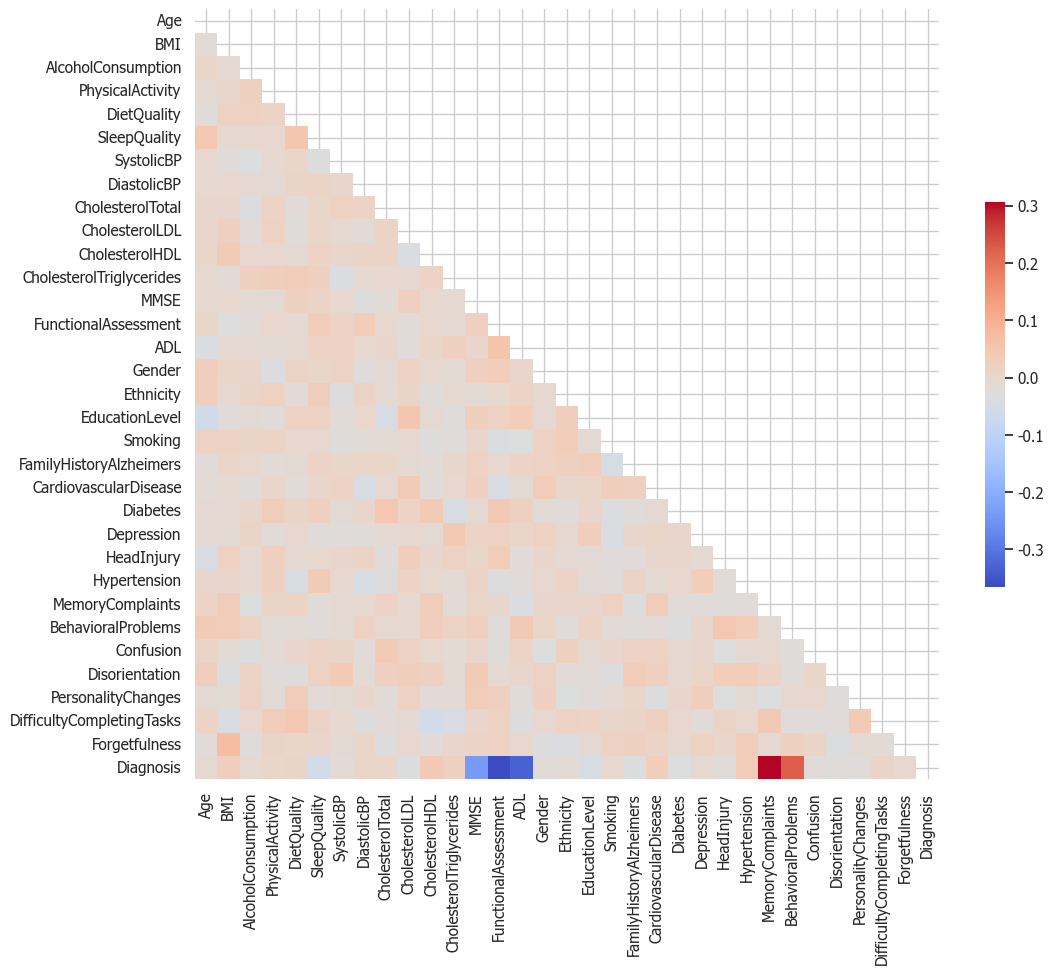

In [10]:
# รวมคอลัมน์ตัวเลขทั้งหมดที่ต้องการดู Correlation
all_numeric_cols = continuous_cols + discrete_cols

# คำนวณเฉพาะคอลัมน์เหล่านี้
correlation_matrix = df[all_numeric_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", cbar_kws={"shrink": 0.5}, mask=mask)
plt.show()

## 4. Decision Tree Classifier


#################### Split 70:30 ####################

===== Decision Tree: criterion=gini, changing max_depth =====
max_depth=1          acc=0.6822  f1=0.6211  precision=0.5367  recall=0.7368  roc_auc=0.6946
max_depth=2          acc=0.7767  f1=0.6327  precision=0.7561  recall=0.5439  roc_auc=0.8135
max_depth=3          acc=0.8930  f1=0.8345  precision=0.9206  recall=0.7632  roc_auc=0.9201
max_depth=4          acc=0.9395  f1=0.9143  precision=0.9163  recall=0.9123  roc_auc=0.9436
max_depth=5          acc=0.9457  f1=0.9217  precision=0.9406  recall=0.9035  roc_auc=0.9316
max_depth=10         acc=0.9116  f1=0.8702  precision=0.9052  recall=0.8377  roc_auc=0.9040
max_depth=30         acc=0.9101  f1=0.8700  precision=0.8899  recall=0.8509  roc_auc=0.8967
max_depth=50         acc=0.9101  f1=0.8700  precision=0.8899  recall=0.8509  roc_auc=0.8967
max_depth=100        acc=0.9101  f1=0.8700  precision=0.8899  recall=0.8509  roc_auc=0.8967

===== Decision Tree: criterion=entropy, changing max_

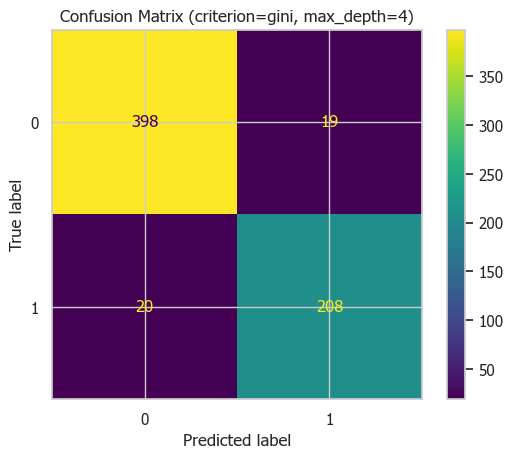

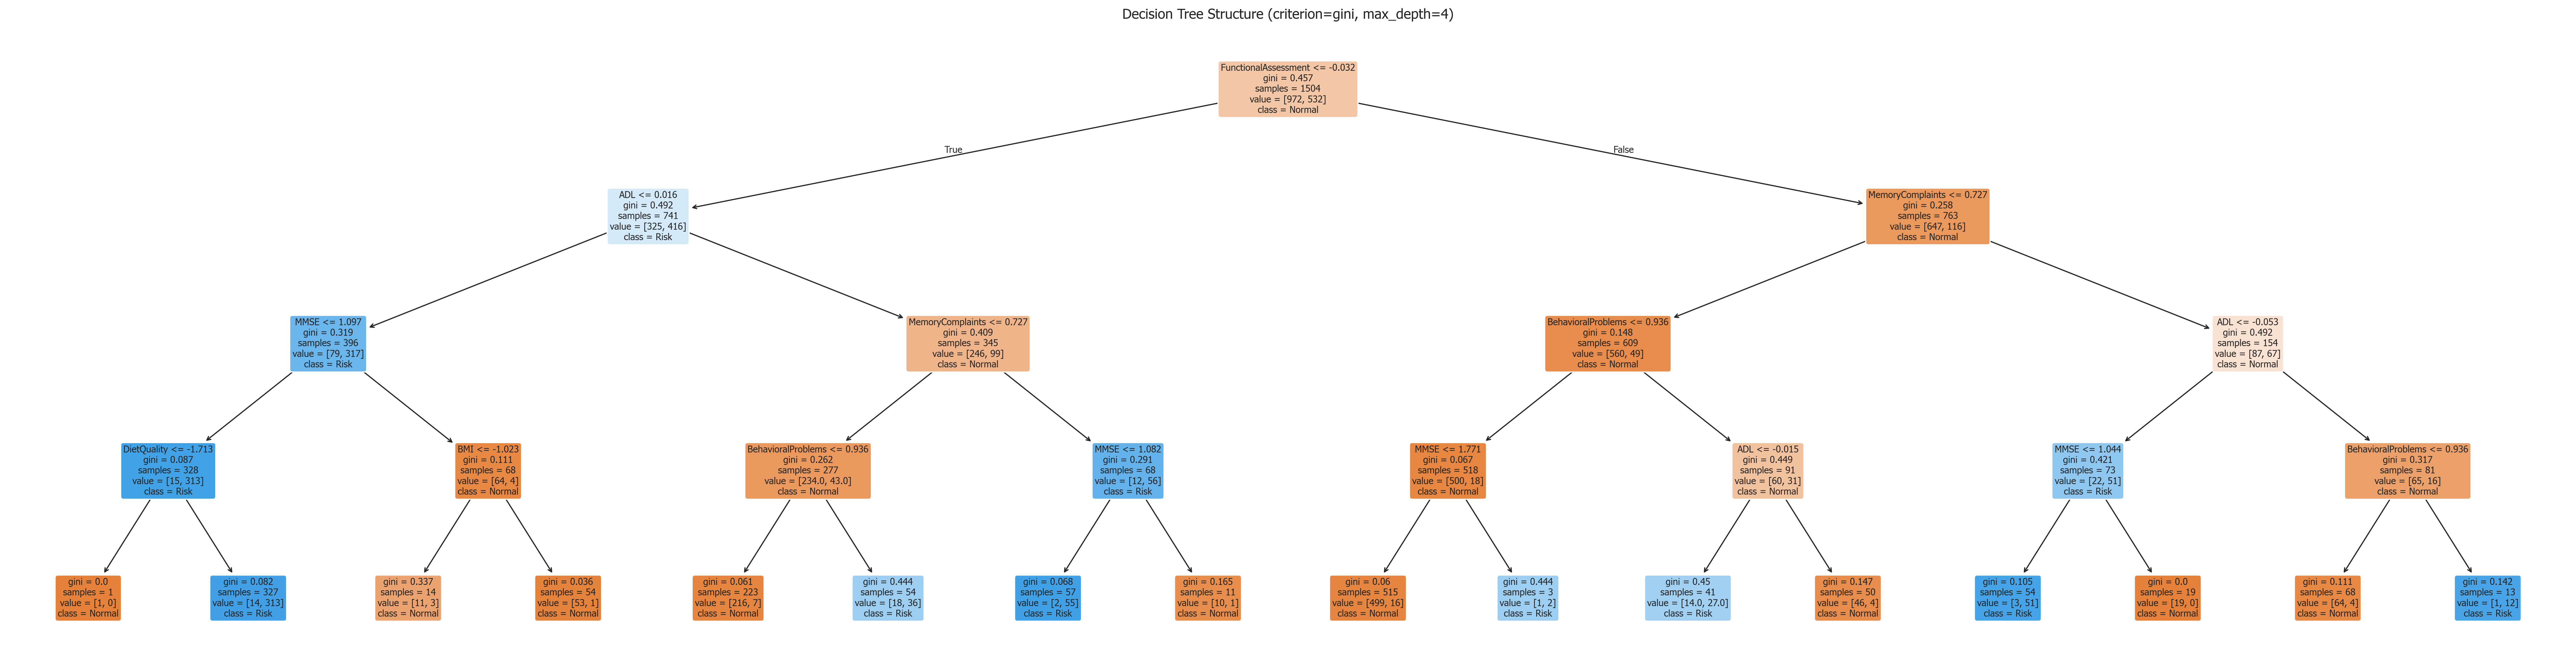


#################### Split 80:20 ####################

===== Decision Tree: criterion=gini, changing max_depth =====
max_depth=1          acc=0.6651  f1=0.6108  precision=0.5183  recall=0.7434  roc_auc=0.6829
max_depth=2          acc=0.7744  f1=0.6421  precision=0.7311  recall=0.5724  roc_auc=0.8081
max_depth=3          acc=0.8907  f1=0.8351  precision=0.8947  recall=0.7829  roc_auc=0.9130
max_depth=4          acc=0.9349  f1=0.9079  precision=0.9079  recall=0.9079  roc_auc=0.9433
max_depth=5          acc=0.9442  f1=0.9200  precision=0.9324  recall=0.9079  roc_auc=0.9357
max_depth=10         acc=0.9349  f1=0.9054  precision=0.9306  recall=0.8816  roc_auc=0.9206
max_depth=30         acc=0.9163  f1=0.8792  precision=0.8973  recall=0.8618  roc_auc=0.9039
max_depth=50         acc=0.9163  f1=0.8792  precision=0.8973  recall=0.8618  roc_auc=0.9039
max_depth=100        acc=0.9163  f1=0.8792  precision=0.8973  recall=0.8618  roc_auc=0.9039

===== Decision Tree: criterion=entropy, changing max_

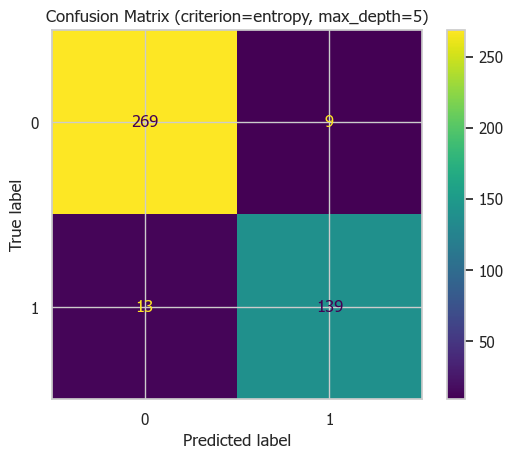

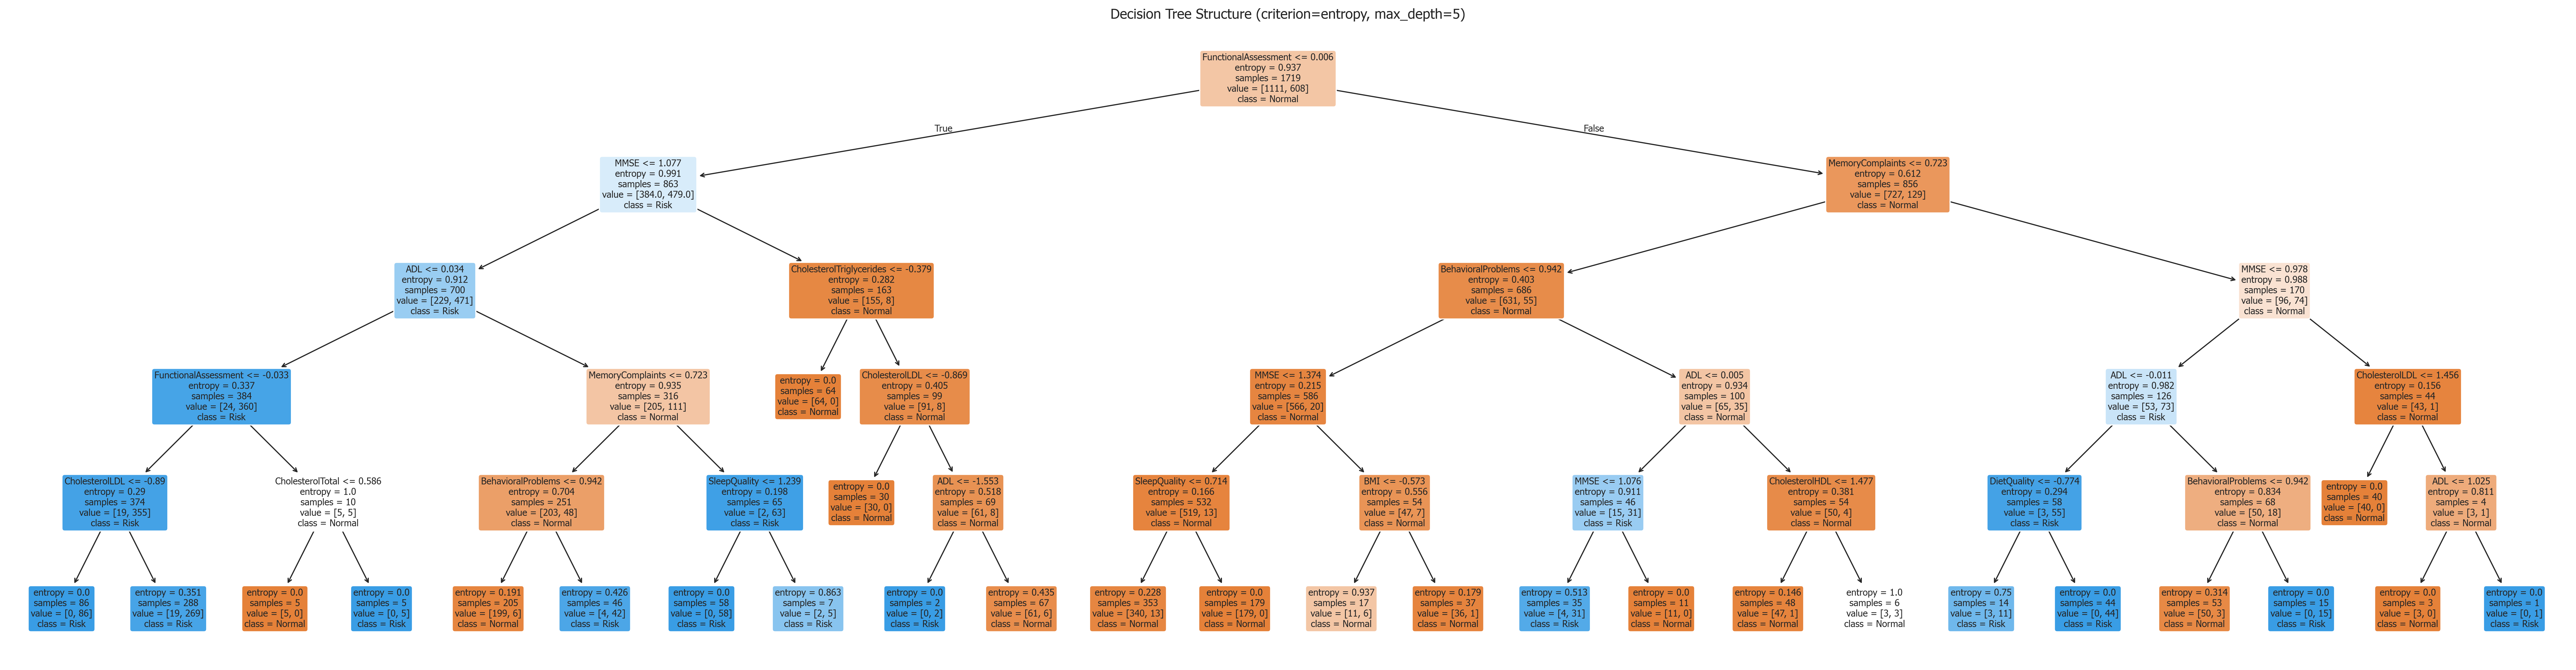


#################### Split 90:10 ####################

===== Decision Tree: criterion=gini, changing max_depth =====
max_depth=1          acc=0.6698  f1=0.6162  precision=0.5229  recall=0.7500  roc_auc=0.6879
max_depth=2          acc=0.7628  f1=0.6871  precision=0.6437  recall=0.7368  roc_auc=0.7911
max_depth=3          acc=0.8372  f1=0.7368  precision=0.8596  recall=0.6447  roc_auc=0.8837
max_depth=4          acc=0.9163  f1=0.8767  precision=0.9143  recall=0.8421  roc_auc=0.9152
max_depth=5          acc=0.9442  f1=0.9211  precision=0.9211  recall=0.9211  roc_auc=0.9364
max_depth=10         acc=0.9395  f1=0.9128  precision=0.9315  recall=0.8947  roc_auc=0.9293
max_depth=30         acc=0.8977  f1=0.8514  precision=0.8750  recall=0.8289  roc_auc=0.8821
max_depth=50         acc=0.8977  f1=0.8514  precision=0.8750  recall=0.8289  roc_auc=0.8821
max_depth=100        acc=0.8977  f1=0.8514  precision=0.8750  recall=0.8289  roc_auc=0.8821

===== Decision Tree: criterion=entropy, changing max_

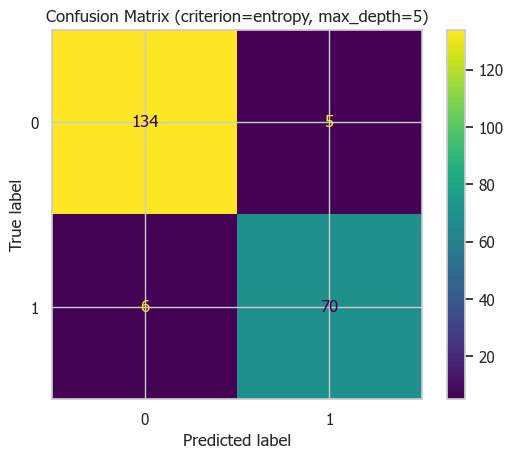

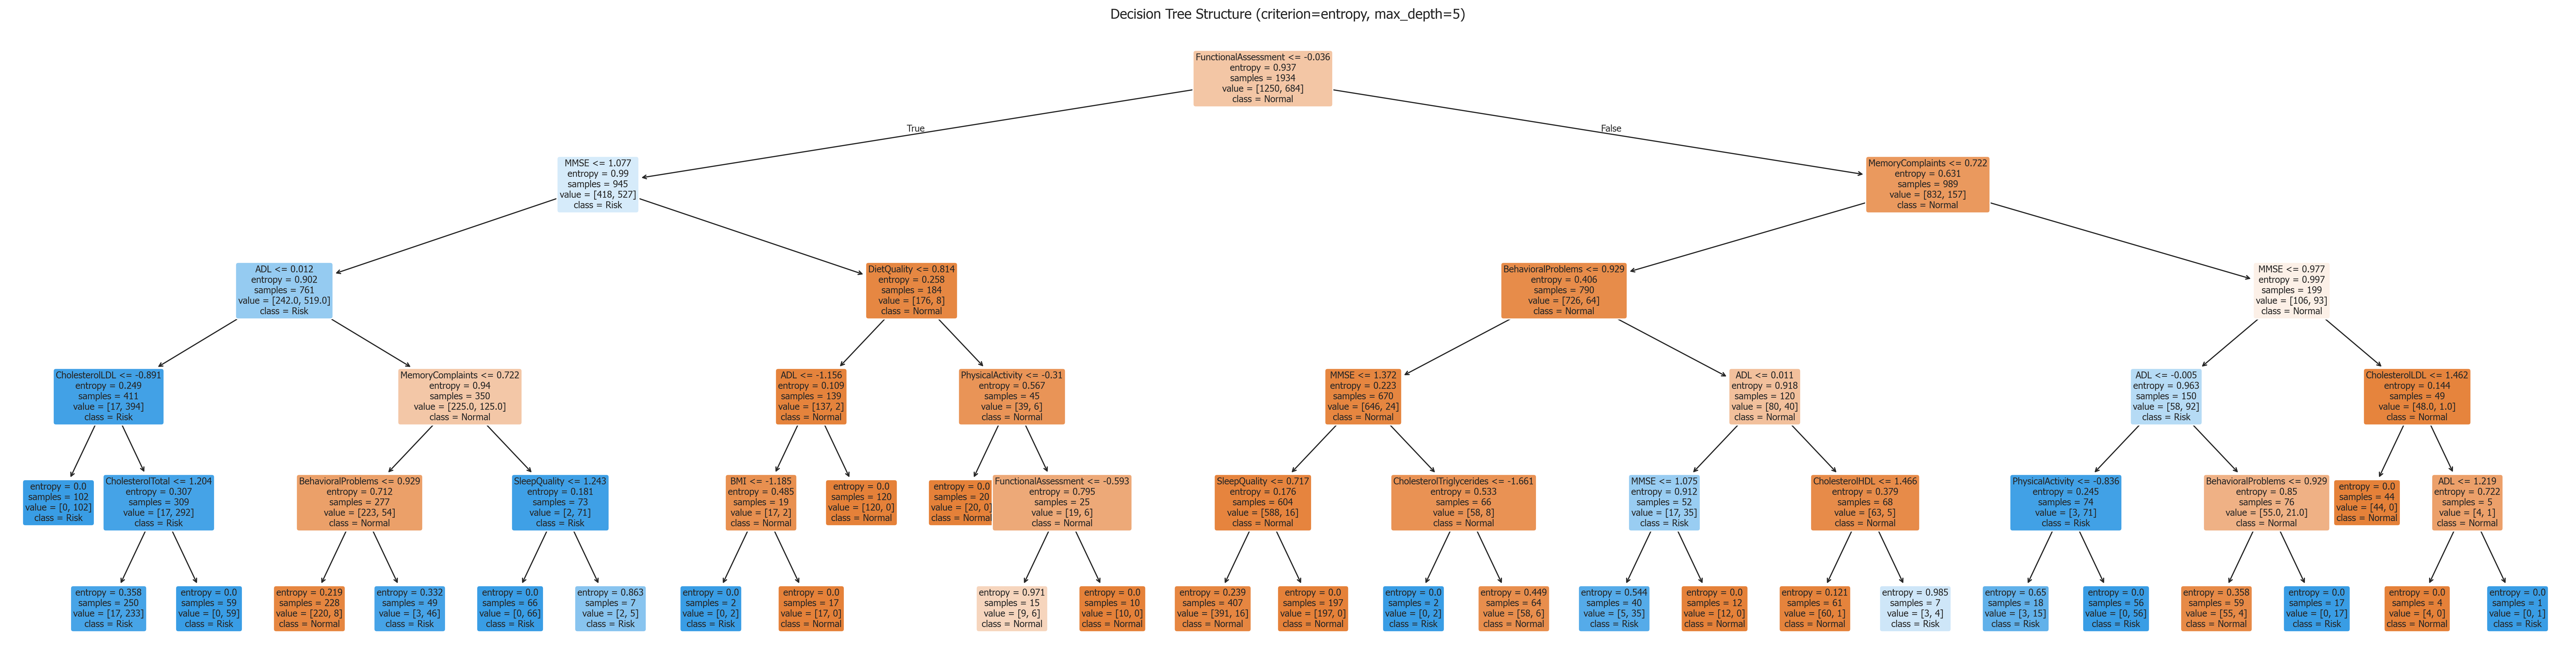


#################### Split 95:5 ####################

===== Decision Tree: criterion=gini, changing max_depth =====
max_depth=1          acc=0.6759  f1=0.6154  precision=0.5283  recall=0.7368  roc_auc=0.6898
max_depth=2          acc=0.7407  f1=0.6585  precision=0.6136  recall=0.7105  roc_auc=0.7620
max_depth=3          acc=0.7963  f1=0.6857  precision=0.7500  recall=0.6316  roc_auc=0.8568
max_depth=4          acc=0.8981  f1=0.8533  precision=0.8649  recall=0.8421  roc_auc=0.9004
max_depth=5          acc=0.9352  f1=0.9114  precision=0.8780  recall=0.9474  roc_auc=0.9180
max_depth=10         acc=0.9259  f1=0.8947  precision=0.8947  recall=0.8947  roc_auc=0.9111
max_depth=30         acc=0.9167  f1=0.8831  precision=0.8718  recall=0.8947  roc_auc=0.9117
max_depth=50         acc=0.9167  f1=0.8831  precision=0.8718  recall=0.8947  roc_auc=0.9117
max_depth=100        acc=0.9167  f1=0.8831  precision=0.8718  recall=0.8947  roc_auc=0.9117

===== Decision Tree: criterion=entropy, changing max_d

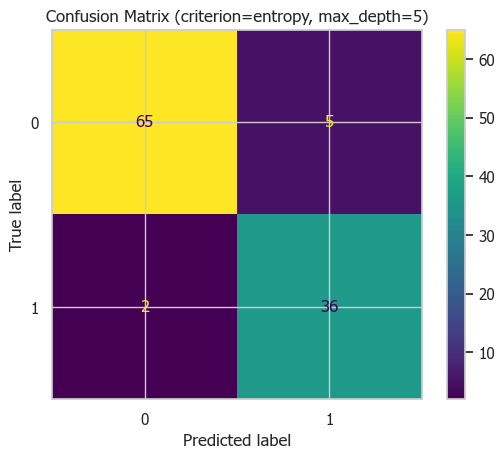

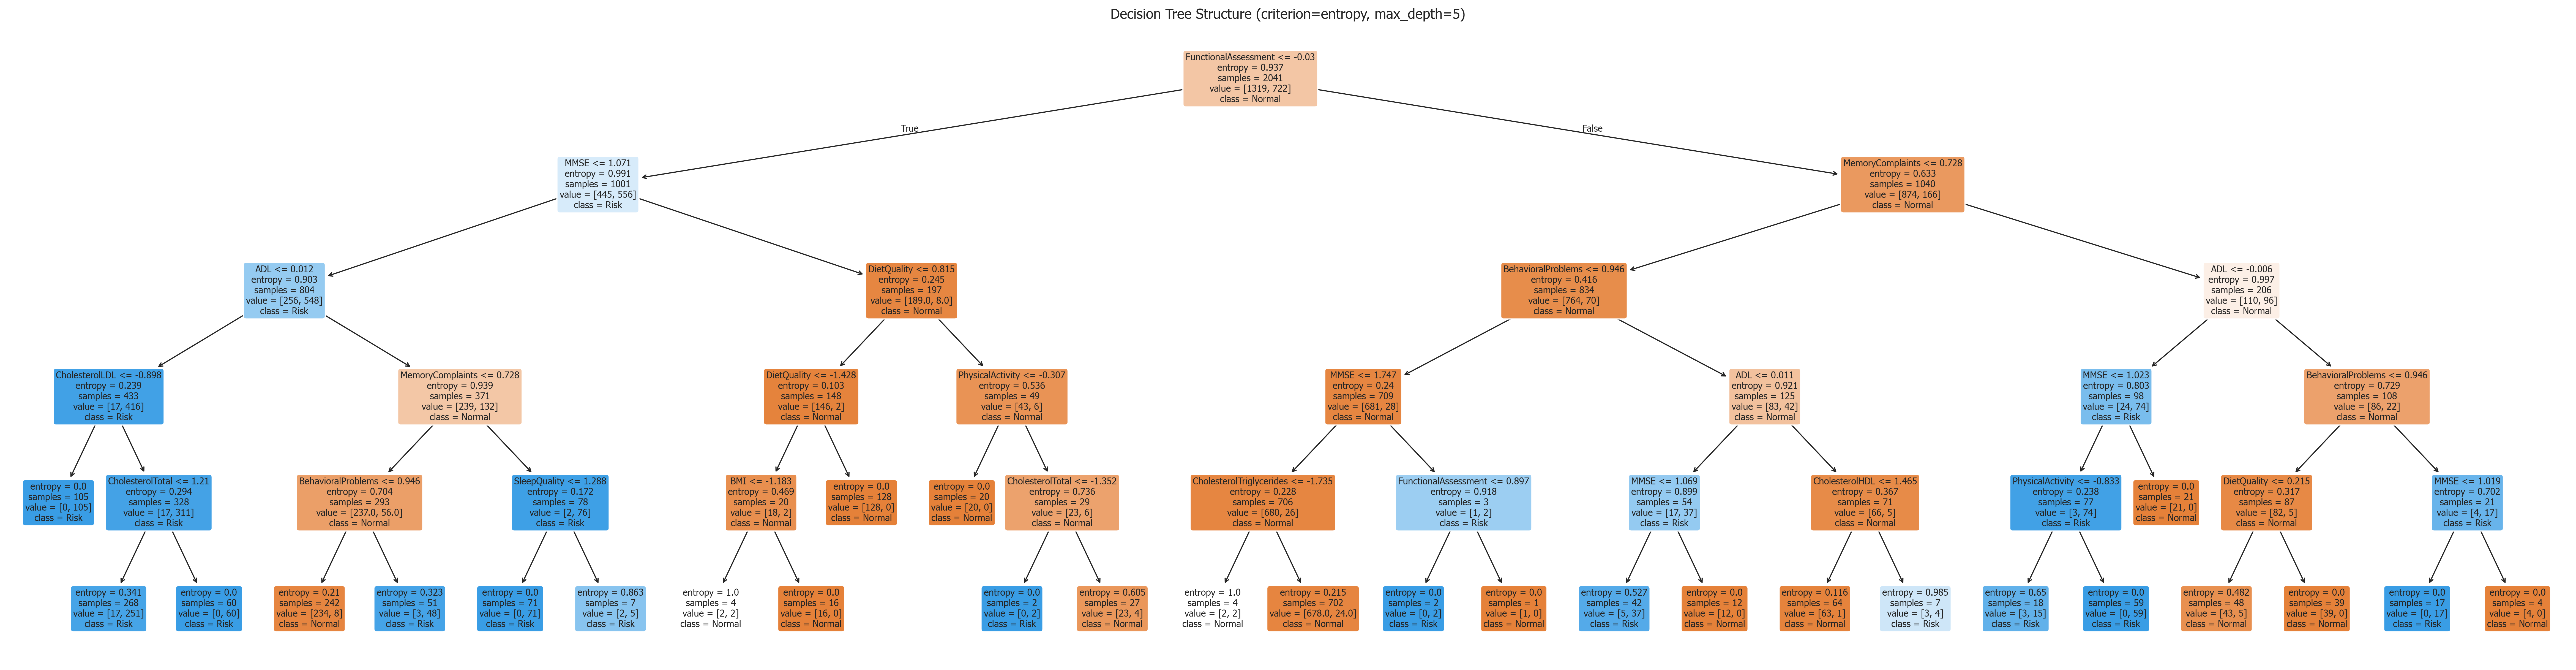


#################### BEST MODEL ACROSS ALL SPLITS ####################
===== Best model: criterion=entropy, max_depth=5, split=80:20 =====
max_depth=5          acc=0.9488  f1=0.9267  precision=0.9392  recall=0.9145  roc_auc=0.9513


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Diagnosis", "PatientID", "DoctorInCharge"], errors="ignore")
Y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]
max_depth_list = [1, 2, 3, 4, 5, 10, 30, 50, 100]
criteria = ["gini", "entropy", "log_loss"]

SELECTION_METRIC = "roc_auc"


def compute_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def print_metrics(tag, m):
    print(
        f"{tag:<20s} acc={m['accuracy']:.4f}  f1={m['f1']:.4f}  "
        f"precision={m['precision']:.4f}  recall={m['recall']:.4f}  roc_auc={m['roc_auc']:.4f}"
    )


all_results = []  # accumulate every run across every split, to find the best model overall

for test_size in split_ratios:
    print(f"\n{'#' * 20} Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=0, stratify=Y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    results = []
    for crit in criteria:
        print(f"\n===== Decision Tree: criterion={crit}, changing max_depth =====")
        for depth in max_depth_list:
            clf = DecisionTreeClassifier(max_depth=int(depth), random_state=0, criterion=crit)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_score = clf.predict_proba(X_test)[:, 1]
            m = compute_metrics(y_test, y_pred, y_score)
            print_metrics(f"max_depth={depth}", m)
            results.append({"criterion": crit, "max_depth": depth, "model": clf, **m})

    results_df = pd.DataFrame(results)
    best_idx = results_df[SELECTION_METRIC].idxmax()
    best_row = results_df.loc[best_idx]
    best_crit = best_row["criterion"]
    best_depth = int(best_row["max_depth"])
    best_clf = best_row["model"]

    print(f"\n===== Best model: criterion={best_crit}, max_depth={best_depth} =====")
    print_metrics(f"max_depth={best_depth}", best_row[
        ["accuracy", "f1", "precision", "recall", "roc_auc"]
    ])

    print("\n----- Best depth per criterion (this split) -----")
    for crit in criteria:
        sub = results_df[results_df["criterion"] == crit]
        best_sub = sub.loc[sub[SELECTION_METRIC].idxmax()]
        print(
            f"  {crit:<10s} best_depth={int(best_sub['max_depth']):<3d} "
            f"{SELECTION_METRIC}={best_sub[SELECTION_METRIC]:.4f}"
        )

    best_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=0, criterion=best_crit)
    best_clf.fit(X_train, y_train)
    Y_predict = best_clf.predict(X_test)
    Y_score = best_clf.predict_proba(X_test)[:, 1]

    ConfusionMatrixDisplay.from_predictions(y_test, Y_predict)
    plt.title(f"Confusion Matrix (criterion={best_crit}, max_depth={best_depth})")
    plt.show()

    plt.figure(figsize=(40, 10), dpi=300)
    plot_tree(
        best_clf,
        feature_names=X.columns,
        class_names=["Normal", "Risk"],
        filled=True,
        rounded=True,
        fontsize=8,
    )
    plt.title(f"Decision Tree Structure (criterion={best_crit}, max_depth={best_depth})")
    plt.show()

    results_df["test_size"] = test_size
    all_results.append(results_df.drop(columns=["model"]))

all_results_df = pd.concat(all_results, ignore_index=True)
best_overall_idx = all_results_df[SELECTION_METRIC].idxmax()
best_overall = all_results_df.loc[best_overall_idx]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: criterion={best_overall['criterion']}, max_depth={int(best_overall['max_depth'])}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print_metrics(
    f"max_depth={int(best_overall['max_depth'])}",
    best_overall[["accuracy", "f1", "precision", "recall", "roc_auc"]],
)


## 5. SVM Classifier


#################### Split 70:30 ####################

===== SVM: kernel=rbf, changing C =====
C=0.01               acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.8871
C=0.1                acc=0.7070  f1=0.2974  precision=0.9756  recall=0.1754  roc_auc=0.8871
C=1                  acc=0.8279  f1=0.7363  precision=0.8031  recall=0.6798  roc_auc=0.8853
C=5                  acc=0.8109  f1=0.7202  precision=0.7548  recall=0.6886  roc_auc=0.8687
C=10                 acc=0.8047  f1=0.7136  precision=0.7406  recall=0.6886  roc_auc=0.8637
C=20                 acc=0.8000  f1=0.7048  precision=0.7368  recall=0.6754  roc_auc=0.8592
C=50                 acc=0.8000  f1=0.7048  precision=0.7368  recall=0.6754  roc_auc=0.8592
C=100                acc=0.8000  f1=0.7048  precision=0.7368  recall=0.6754  roc_auc=0.8592
C=500                acc=0.8000  f1=0.7048  precision=0.7368  recall=0.6754  roc_auc=0.8592
C=1000               acc=0.8000  f1=0.7048  precision=0.7368  recall=0.6754 

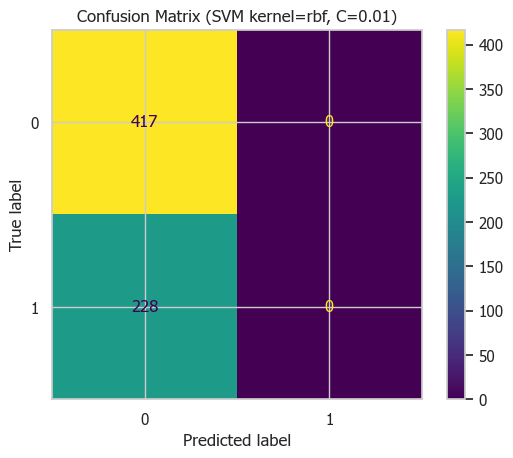


#################### Split 80:20 ####################

===== SVM: kernel=rbf, changing C =====
C=0.01               acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.8822
C=0.1                acc=0.7512  f1=0.4623  precision=0.9787  recall=0.3026  roc_auc=0.8824
C=1                  acc=0.8279  f1=0.7431  precision=0.7868  recall=0.7039  roc_auc=0.8841
C=5                  acc=0.7953  f1=0.7027  precision=0.7222  recall=0.6842  roc_auc=0.8705
C=10                 acc=0.7953  f1=0.6986  precision=0.7286  recall=0.6711  roc_auc=0.8635
C=20                 acc=0.8023  f1=0.7079  precision=0.7410  recall=0.6776  roc_auc=0.8554
C=50                 acc=0.8023  f1=0.7079  precision=0.7410  recall=0.6776  roc_auc=0.8554
C=100                acc=0.8023  f1=0.7079  precision=0.7410  recall=0.6776  roc_auc=0.8554
C=500                acc=0.8023  f1=0.7079  precision=0.7410  recall=0.6776  roc_auc=0.8554
C=1000               acc=0.8023  f1=0.7079  precision=0.7410  recall=0.6776 

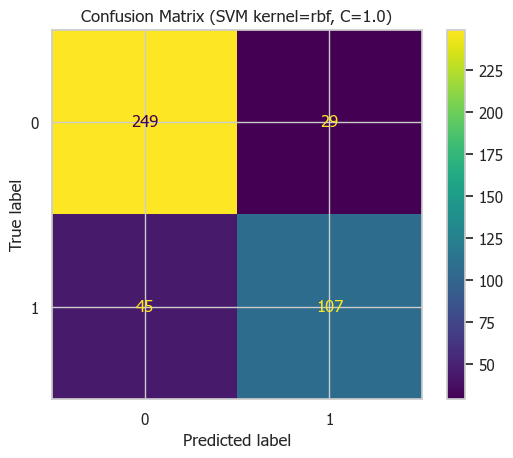


#################### Split 90:10 ####################

===== SVM: kernel=rbf, changing C =====
C=0.01               acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.8862
C=0.1                acc=0.7767  f1=0.5556  precision=0.9375  recall=0.3947  roc_auc=0.8864
C=1                  acc=0.8465  f1=0.7591  precision=0.8525  recall=0.6842  roc_auc=0.8849
C=5                  acc=0.8233  f1=0.7432  precision=0.7639  recall=0.7237  roc_auc=0.8627
C=10                 acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8591
C=20                 acc=0.8186  f1=0.7347  precision=0.7606  recall=0.7105  roc_auc=0.8525
C=50                 acc=0.8140  f1=0.7297  precision=0.7500  recall=0.7105  roc_auc=0.8523
C=100                acc=0.8140  f1=0.7297  precision=0.7500  recall=0.7105  roc_auc=0.8523
C=500                acc=0.8140  f1=0.7297  precision=0.7500  recall=0.7105  roc_auc=0.8523
C=1000               acc=0.8140  f1=0.7297  precision=0.7500  recall=0.7105 

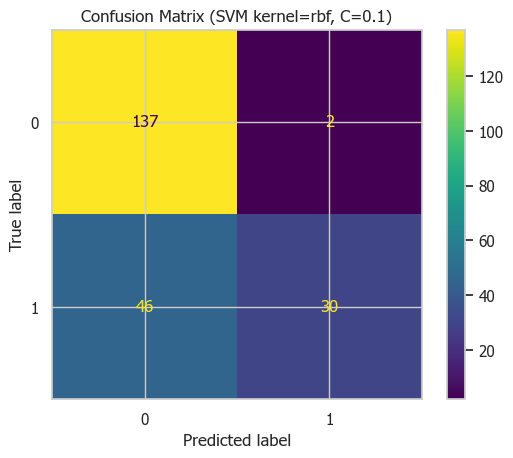


#################### Split 95:5 ####################

===== SVM: kernel=rbf, changing C =====
C=0.01               acc=0.6481  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.8925
C=0.1                acc=0.7963  f1=0.6207  precision=0.9000  recall=0.4737  roc_auc=0.8921
C=1                  acc=0.8426  f1=0.7733  precision=0.7838  recall=0.7632  roc_auc=0.8944
C=5                  acc=0.8241  f1=0.7467  precision=0.7568  recall=0.7368  roc_auc=0.8613
C=10                 acc=0.8148  f1=0.7368  precision=0.7368  recall=0.7368  roc_auc=0.8579
C=20                 acc=0.7963  f1=0.7027  precision=0.7222  recall=0.6842  roc_auc=0.8508
C=50                 acc=0.7963  f1=0.7027  precision=0.7222  recall=0.6842  roc_auc=0.8508
C=100                acc=0.7963  f1=0.7027  precision=0.7222  recall=0.6842  roc_auc=0.8508
C=500                acc=0.7963  f1=0.7027  precision=0.7222  recall=0.6842  roc_auc=0.8508
C=1000               acc=0.7963  f1=0.7027  precision=0.7222  recall=0.6842  

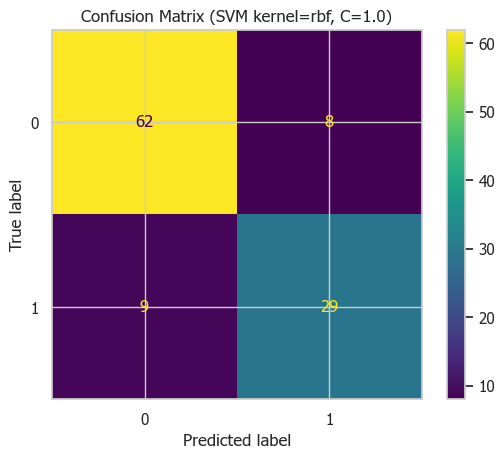


#################### BEST MODEL ACROSS ALL SPLITS ####################
===== Best model: kernel=rbf, C=1.0, split=95:5 =====
C=1.0                acc=0.8426  f1=0.7733  precision=0.7838  recall=0.7632  roc_auc=0.8944


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")


def print_metrics(tag, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_score)
    print(f"{tag:<20s} acc={acc:.4f}  f1={f1:.4f}  precision={prec:.4f}  recall={rec:.4f}  roc_auc={roc:.4f}")
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec, "roc_auc": roc}

X = df.drop(columns=["Diagnosis", "PatientID", "DoctorInCharge"], errors="ignore")
Y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]
c_values = [0.01, 0.1, 1, 5, 10, 20, 50, 100, 500, 1000]
kernels = ["rbf", "poly", "sigmoid"]

SELECTION_METRIC = "roc_auc"

all_results = []  # accumulate every run across every split, to find the best model overall

for test_size in split_ratios:
    print(f"\n{'#' * 20} Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} {'#' * 20}")

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=0, stratify=Y
    )

    # ปรับสเกลข้อมูล
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # 2. ลูปทดสอบทั้ง kernel และค่า C
    results = []
    for kernel in kernels:
        print(f"\n===== SVM: kernel={kernel}, changing C =====")
        for c in c_values:
            clf = SVC(C=c, kernel=kernel, random_state=0)
            clf.fit(X_train, y_train)
            y_pred_loop = clf.predict(X_test)
            y_score_loop = clf.decision_function(X_test)
            m = print_metrics(f"C={c}", y_test, y_pred_loop, y_score_loop)
            results.append({"kernel": kernel, "C": c, "model": clf, **m})

    # 3. หาโมเดลที่ดีที่สุดจากทุก kernel/C ใน split
    results_df = pd.DataFrame(results)
    best_idx = results_df[SELECTION_METRIC].idxmax()
    best_row = results_df.loc[best_idx]
    best_kernel = best_row["kernel"]
    best_c = best_row["C"]

    print(f"\n===== Best model: kernel={best_kernel}, C={best_c} =====")
    print_metrics(
        f"C={best_c}",
        y_test,
        results_df.loc[best_idx, "model"].predict(X_test),
        results_df.loc[best_idx, "model"].decision_function(X_test),
    )

    print("\n----- Best C per kernel (this split) -----")
    for kernel in kernels:
        sub = results_df[results_df["kernel"] == kernel]
        best_sub = sub.loc[sub[SELECTION_METRIC].idxmax()]
        print(f"  {kernel:<8s} best_C={best_sub['C']:<6} {SELECTION_METRIC}={best_sub[SELECTION_METRIC]:.4f}")

    # 4. รีฟิตโมเดลที่ดีที่สุดแบบชัดเจน แล้ววาดกราฟ
    best_clf = SVC(C=best_c, kernel=best_kernel, random_state=0)
    best_clf.fit(X_train, y_train)
    Y_predict = best_clf.predict(X_test)
    Y_score = best_clf.decision_function(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, Y_predict)
    plt.title(f"Confusion Matrix (SVM kernel={best_kernel}, C={best_c})")
    plt.show()

    results_df["test_size"] = test_size
    all_results.append(results_df.drop(columns=["model"]))

all_results_df = pd.concat(all_results, ignore_index=True)
best_overall_idx = all_results_df[SELECTION_METRIC].idxmax()
best_overall = all_results_df.loc[best_overall_idx]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: kernel={best_overall['kernel']}, C={best_overall['C']}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print(
    f"{'C=' + str(best_overall['C']):<20s} acc={best_overall['accuracy']:.4f}  f1={best_overall['f1']:.4f}  "
    f"precision={best_overall['precision']:.4f}  recall={best_overall['recall']:.4f}  roc_auc={best_overall['roc_auc']:.4f}"
)


## 6. Neural Network (MLP)


#################### Split 70:30 ####################

===== MLP: activation=identity, changing hidden_layer_sizes =====
hidden_layer_sizes=(5,)                       acc=0.8279  f1=0.7436  precision=0.7854  recall=0.7061  roc_auc=0.8824
hidden_layer_sizes=(5, 5)                     acc=0.8326  f1=0.7523  precision=0.7885  recall=0.7193  roc_auc=0.8824
hidden_layer_sizes=(10,)                      acc=0.8295  f1=0.7477  precision=0.7837  recall=0.7149  roc_auc=0.8824
hidden_layer_sizes=(50,)                      acc=0.8295  f1=0.7489  precision=0.7810  recall=0.7193  roc_auc=0.8818
hidden_layer_sizes=(100,)                     acc=0.8264  f1=0.7431  precision=0.7788  recall=0.7105  roc_auc=0.8825
hidden_layer_sizes=(50, 50)                   acc=0.8264  f1=0.7431  precision=0.7788  recall=0.7105  roc_auc=0.8816
hidden_layer_sizes=(100, 100, 100)            acc=0.8233  f1=0.7385  precision=0.7740  recall=0.7061  roc_auc=0.8777
hidden_layer_sizes=(100, 100, 100, 100)       acc=0.8155  f

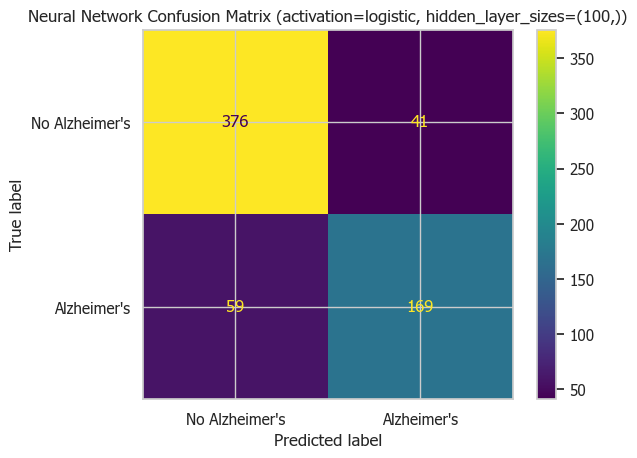


#################### Split 80:20 ####################

===== MLP: activation=identity, changing hidden_layer_sizes =====
hidden_layer_sizes=(5,)                       acc=0.8279  f1=0.7448  precision=0.7826  recall=0.7105  roc_auc=0.8795
hidden_layer_sizes=(5, 5)                     acc=0.8256  f1=0.7440  precision=0.7730  recall=0.7171  roc_auc=0.8796
hidden_layer_sizes=(10,)                      acc=0.8279  f1=0.7466  precision=0.7786  recall=0.7171  roc_auc=0.8800
hidden_layer_sizes=(50,)                      acc=0.8279  f1=0.7448  precision=0.7826  recall=0.7105  roc_auc=0.8795
hidden_layer_sizes=(100,)                     acc=0.8209  f1=0.7354  precision=0.7698  recall=0.7039  roc_auc=0.8801
hidden_layer_sizes=(50, 50)                   acc=0.8256  f1=0.7440  precision=0.7730  recall=0.7171  roc_auc=0.8802
hidden_layer_sizes=(100, 100, 100)            acc=0.8256  f1=0.7440  precision=0.7730  recall=0.7171  roc_auc=0.8785
hidden_layer_sizes=(100, 100, 100, 100)       acc=0.8209  f

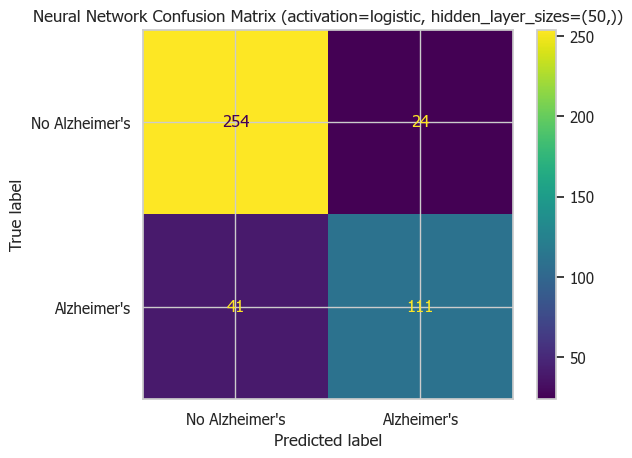


#################### Split 90:10 ####################

===== MLP: activation=identity, changing hidden_layer_sizes =====
hidden_layer_sizes=(5,)                       acc=0.8465  f1=0.7724  precision=0.8116  recall=0.7368  roc_auc=0.8851
hidden_layer_sizes=(5, 5)                     acc=0.8419  f1=0.7671  precision=0.8000  recall=0.7368  roc_auc=0.8852
hidden_layer_sizes=(10,)                      acc=0.8512  f1=0.7778  precision=0.8235  recall=0.7368  roc_auc=0.8851
hidden_layer_sizes=(50,)                      acc=0.8419  f1=0.7671  precision=0.8000  recall=0.7368  roc_auc=0.8841
hidden_layer_sizes=(100,)                     acc=0.8465  f1=0.7724  precision=0.8116  recall=0.7368  roc_auc=0.8869
hidden_layer_sizes=(50, 50)                   acc=0.8372  f1=0.7619  precision=0.7887  recall=0.7368  roc_auc=0.8870
hidden_layer_sizes=(100, 100, 100)            acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8817
hidden_layer_sizes=(100, 100, 100, 100)       acc=0.8419  f

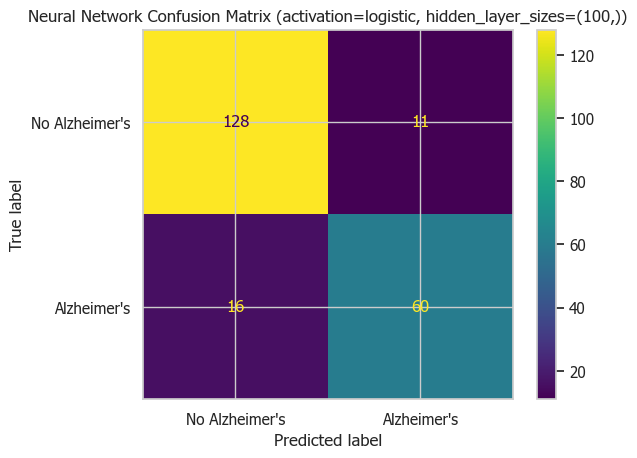


#################### Split 95:5 ####################

===== MLP: activation=identity, changing hidden_layer_sizes =====
hidden_layer_sizes=(5,)                       acc=0.8333  f1=0.7632  precision=0.7632  recall=0.7632  roc_auc=0.8977
hidden_layer_sizes=(5, 5)                     acc=0.8241  f1=0.7532  precision=0.7436  recall=0.7632  roc_auc=0.8940
hidden_layer_sizes=(10,)                      acc=0.8241  f1=0.7467  precision=0.7568  recall=0.7368  roc_auc=0.8944
hidden_layer_sizes=(50,)                      acc=0.8333  f1=0.7632  precision=0.7632  recall=0.7632  roc_auc=0.8917
hidden_layer_sizes=(100,)                     acc=0.8148  f1=0.7368  precision=0.7368  recall=0.7368  roc_auc=0.8981
hidden_layer_sizes=(50, 50)                   acc=0.8241  f1=0.7467  precision=0.7568  recall=0.7368  roc_auc=0.8876
hidden_layer_sizes=(100, 100, 100)            acc=0.8426  f1=0.7792  precision=0.7692  recall=0.7895  roc_auc=0.8944
hidden_layer_sizes=(100, 100, 100, 100)       acc=0.8333  f1

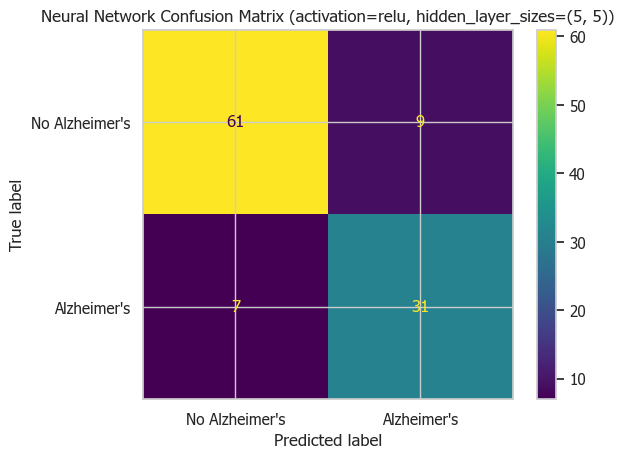


#################### BEST MODEL ACROSS ALL SPLITS ####################
===== Best model: activation=logistic, hidden_layer_sizes=(100,), split=90:10 =====
hidden_layer_sizes=(100,)                     acc=0.8744  f1=0.8163  precision=0.8451  recall=0.7895  roc_auc=0.9129


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def print_metrics(tag, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_score)
    print(f"{tag:<45s} acc={acc:.4f}  f1={f1:.4f}  precision={prec:.4f}  recall={rec:.4f}  roc_auc={roc:.4f}")
    return acc, f1, prec, rec, roc

df = pd.read_csv("alzheimers_disease_data.csv")

X = df.drop(columns=["PatientID", "DoctorInCharge", "Diagnosis"])
y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]

all_runs = []  # accumulate every run across every split, to find the best model overall

for test_size in split_ratios:
    print(f"\n{'#' * 20} Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0, stratify = y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    layer_list = [(5,) ,(5,5) ,(10,), (50,), (100,), (50,50), (100,100,100), (100,100,100,100)]
    activations = ["identity", "logistic", "tanh", "relu"]
    mlp_acc, mlp_f1, mlp_prec, mlp_rec, mlp_roc, mlp_keys = [], [], [], [], [], []
    mlp_models = {}

    for activation in activations:
        print(f"\n===== MLP: activation={activation}, changing hidden_layer_sizes =====")
        for layers in layer_list:
            model = MLPClassifier(hidden_layer_sizes=layers, activation=activation, max_iter=500, random_state=0)
            model.fit(X_train, y_train)
            key = (activation, layers)
            mlp_models[key] = model

            test_pred = model.predict(X_test)
            test_score = model.predict_proba(X_test)[:, 1]

            acc, f1, prec, rec, roc = print_metrics(
                f"hidden_layer_sizes={layers}", y_test, test_pred, test_score
            )
            mlp_acc.append(acc)
            mlp_f1.append(f1)
            mlp_prec.append(prec)
            mlp_rec.append(rec)
            mlp_roc.append(roc)
            mlp_keys.append(key)
            all_runs.append({
                "activation": activation, "hidden_layer_sizes": layers, "test_size": test_size,
                "accuracy": acc, "f1": f1, "precision": prec, "recall": rec, "roc_auc": roc,
            })

    best_activation, best_layers = mlp_keys[mlp_acc.index(max(mlp_acc))]
    best_mlp_pred = mlp_models[(best_activation, best_layers)].predict(X_test)
    best_mlp_score = mlp_models[(best_activation, best_layers)].predict_proba(X_test)[:, 1]

    print(f"\n===== Best model: activation={best_activation}, hidden_layer_sizes={best_layers} =====")
    print_metrics(f"hidden_layer_sizes={best_layers}", y_test, best_mlp_pred, best_mlp_score)

    cm = confusion_matrix(y_test, best_mlp_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No Alzheimer's", "Alzheimer's"]
    ).plot()
    plt.title(f"Neural Network Confusion Matrix (activation={best_activation}, hidden_layer_sizes={best_layers})")
    plt.show()

all_runs_df = pd.DataFrame(all_runs)
best_overall_idx = all_runs_df["accuracy"].idxmax()
best_overall = all_runs_df.loc[best_overall_idx]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: activation={best_overall['activation']}, hidden_layer_sizes={best_overall['hidden_layer_sizes']}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print(
    f"{'hidden_layer_sizes=' + str(best_overall['hidden_layer_sizes']):<45s} "
    f"acc={best_overall['accuracy']:.4f}  f1={best_overall['f1']:.4f}  "
    f"precision={best_overall['precision']:.4f}  recall={best_overall['recall']:.4f}  roc_auc={best_overall['roc_auc']:.4f}"
)


## 7. Ridge & Lasso


#################### Split 70:30 ####################

===== Ridge: changing alpha =====
alpha=0.001          acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=0.01           acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=0.1            acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=1              acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=10             acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8851

===== Lasso: changing alpha =====
alpha=0.001          acc=0.8310  f1=0.7517  precision=0.7820  recall=0.7237  roc_auc=0.8861
alpha=0.01           acc=0.8341  f1=0.7506  precision=0.8010  recall=0.7061  roc_auc=0.8879
alpha=0.1            acc=0.7163  f1=0.4000  precision=0.7922  recall=0.2675  roc_auc=0.8265
alpha=1              acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.5000
alpha=10             acc=0.6465  f1=0.0000  pre

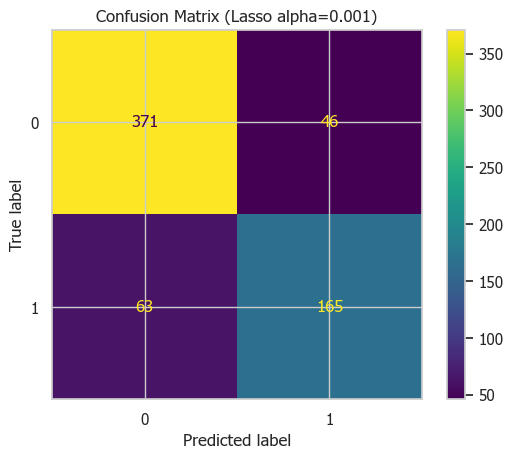


#################### Split 80:20 ####################

===== Ridge: changing alpha =====
alpha=0.001          acc=0.8279  f1=0.7500  precision=0.7708  recall=0.7303  roc_auc=0.8812
alpha=0.01           acc=0.8279  f1=0.7500  precision=0.7708  recall=0.7303  roc_auc=0.8812
alpha=0.1            acc=0.8279  f1=0.7500  precision=0.7708  recall=0.7303  roc_auc=0.8812
alpha=1              acc=0.8279  f1=0.7500  precision=0.7708  recall=0.7303  roc_auc=0.8812
alpha=10             acc=0.8279  f1=0.7500  precision=0.7708  recall=0.7303  roc_auc=0.8814

===== Lasso: changing alpha =====
alpha=0.001          acc=0.8302  f1=0.7525  precision=0.7762  recall=0.7303  roc_auc=0.8818
alpha=0.01           acc=0.8302  f1=0.7456  precision=0.7926  recall=0.7039  roc_auc=0.8797
alpha=0.1            acc=0.7186  f1=0.3858  precision=0.8444  recall=0.2500  roc_auc=0.8297
alpha=1              acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.5000
alpha=10             acc=0.6465  f1=0.0000  pre

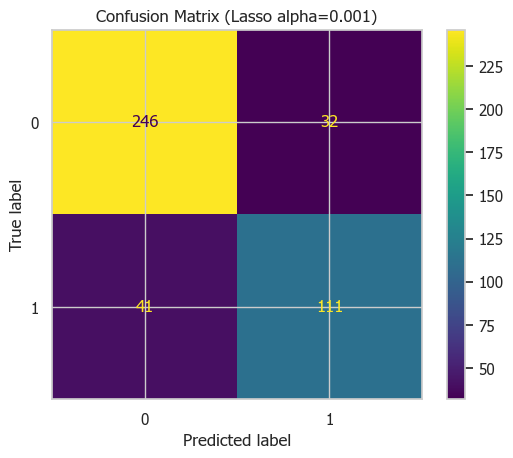


#################### Split 90:10 ####################

===== Ridge: changing alpha =====
alpha=0.001          acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827
alpha=0.01           acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827
alpha=0.1            acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827
alpha=1              acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827
alpha=10             acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827

===== Lasso: changing alpha =====
alpha=0.001          acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8831
alpha=0.01           acc=0.8186  f1=0.7310  precision=0.7681  recall=0.6974  roc_auc=0.8829
alpha=0.1            acc=0.7116  f1=0.3404  precision=0.8889  recall=0.2105  roc_auc=0.8277
alpha=1              acc=0.6465  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.5000
alpha=10             acc=0.6465  f1=0.0000  pre

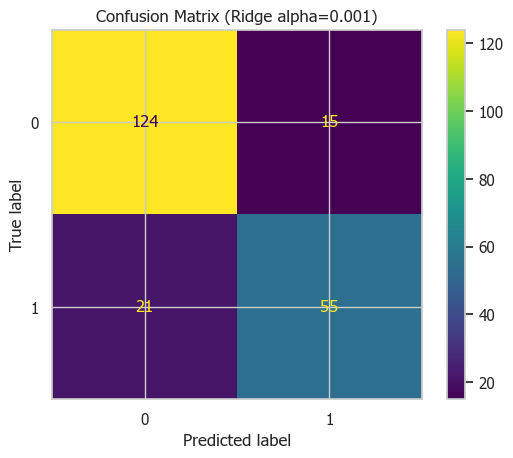


#################### Split 95:5 ####################

===== Ridge: changing alpha =====
alpha=0.001          acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8936
alpha=0.01           acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8936
alpha=0.1            acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8936
alpha=1              acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8936
alpha=10             acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8936

===== Lasso: changing alpha =====
alpha=0.001          acc=0.8148  f1=0.7436  precision=0.7250  recall=0.7632  roc_auc=0.8917
alpha=0.01           acc=0.7963  f1=0.7250  precision=0.6905  recall=0.7632  roc_auc=0.8912
alpha=0.1            acc=0.6852  f1=0.2273  precision=0.8333  recall=0.1316  roc_auc=0.8180
alpha=1              acc=0.6481  f1=0.0000  precision=0.0000  recall=0.0000  roc_auc=0.5000
alpha=10             acc=0.6481  f1=0.0000  prec

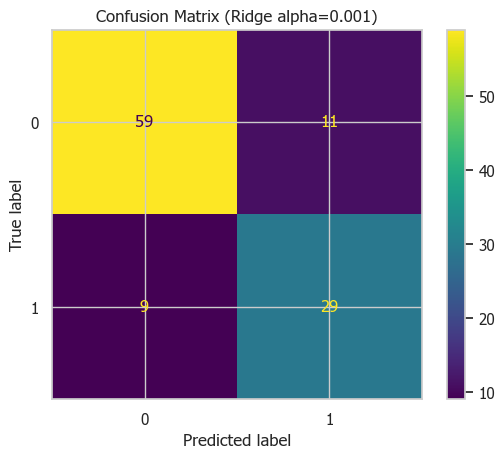


#################### BEST MODEL ACROSS ALL SPLITS ####################
===== Best model: Ridge alpha=0.001, split=90:10 =====
alpha=0.001          acc=0.8326  f1=0.7534  precision=0.7857  recall=0.7237  roc_auc=0.8827


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings

warnings.filterwarnings("ignore")


def print_metrics(tag, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_score)
    print(f"{tag:<20s} acc={acc:.4f}  f1={f1:.4f}  precision={prec:.4f}  recall={rec:.4f}  roc_auc={roc:.4f}")
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec, "roc_auc": roc}

df = pd.read_csv("alzheimers_disease_data.csv")

# รายชื่อหมอที่เป็นคนตรวจไม่ได้มีผลกระทบกับการเป็นโรค ใส่ไว้เป็น placeholder เฉยๆ
# ลำดับของคนไข้ไม่มีผลกับข้อมูลเลย ตัดออกเช่นเดียวกับ DoctorInCharge
X = df.drop(columns=["PatientID", "DoctorInCharge", "Diagnosis"])
y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]
alpha_values = [0.001, 0.01, 0.1, 1, 10]
models = {"Ridge": Ridge, "Lasso": Lasso}

all_runs = []  # accumulate every run across every split, to find the best model overall

for test_size in split_ratios:
    print(f"\n{'#' * 20} Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0 , stratify = y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    best_f1, best_tag, best_pred, best_score = -1, None, None, None

    for name, ModelClass in models.items():
        print(f"\n===== {name}: changing alpha =====")
        for a in alpha_values:
            model = ModelClass(alpha=a)
            model.fit(X_train_scaled, y_train_enc)
            y_score = np.clip(model.predict(X_test_scaled), 0, 1)
            y_pred_labels = le.inverse_transform((y_score >= 0.5).astype(int))

            m = print_metrics(f"alpha={a}", y_test, y_pred_labels, y_score)
            all_runs.append({"model": name, "alpha": a, "test_size": test_size, **m})

            if m["f1"] > best_f1:
                best_f1, best_tag, best_pred, best_score = m["f1"], f"{name} alpha={a}", y_pred_labels, y_score

    print(f"\n===== Best model: {best_tag} =====")
    print_metrics(best_tag, y_test, best_pred, best_score)
    ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
    plt.title(f"Confusion Matrix ({best_tag})")
    plt.show()

all_runs_df = pd.DataFrame(all_runs)
best_overall_idx = all_runs_df["f1"].idxmax()
best_overall = all_runs_df.loc[best_overall_idx]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: {best_overall['model']} alpha={best_overall['alpha']}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print(
    f"{'alpha=' + str(best_overall['alpha']):<20s} acc={best_overall['accuracy']:.4f}  f1={best_overall['f1']:.4f}  "
    f"precision={best_overall['precision']:.4f}  recall={best_overall['recall']:.4f}  roc_auc={best_overall['roc_auc']:.4f}"
)


## 8. Model Comparison Summary

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
import warnings

warnings.filterwarnings("ignore")

def score_and_record(name, param, y_pred, y_score, label=None):
    if label is None:
        label = f"{name}({param})"
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)
    print(f"{label:<45s} acc={acc:.4f}  f1={f1:.4f}  precision={prec:.4f}  recall={rec:.4f}  roc_auc={roc:.4f}")
    results.append((name, param, acc, f1, prec, rec, roc))


df = pd.read_csv("alzheimers_disease_data.csv")
X = df.drop(columns=["PatientID", "DoctorInCharge", "Diagnosis"])
y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]
all_results = []  # accumulate every split's summary, to find the best model across all splits

for test_size in split_ratios:
    print(f"\n{'#' * 20} Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0, stratify = y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    results = []

    print("\n===== Ridge: changing alpha =====")
    for alpha in [0.001, 0.01, 0.1, 1, 10]:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train_enc)
        raw_pred = model.predict(X_test_scaled)
        y_score = np.clip(raw_pred, 0, 1)
        y_pred = (y_score >= 0.5).astype(int)
        score_and_record("Ridge", alpha, y_pred, y_score, label=f"alpha={alpha}")

    print("\n===== Lasso: changing alpha =====")
    for alpha in [0.001, 0.01, 0.1, 1, 10]:
        model = Lasso(alpha=alpha)
        model.fit(X_train_scaled, y_train_enc)
        raw_pred = model.predict(X_test_scaled)
        y_score = np.clip(raw_pred, 0, 1)
        y_pred = (y_score >= 0.5).astype(int)
        score_and_record("Lasso", alpha, y_pred, y_score, label=f"alpha={alpha}")

    for criterion in ["gini", "entropy", "log_loss"]:
        print(f"\n===== Decision Tree: criterion={criterion}, changing max_depth =====")
        for depth in [1,2,3,4,5,10,30,50,100]:
            model = DecisionTreeClassifier(max_depth=depth, criterion=criterion, random_state=0)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_score = model.predict_proba(X_test_scaled)[:, 1]
            score_and_record(f"DecisionTree[{criterion}]", depth, y_pred, y_score, label=f"max_depth={depth}")

    for kernel in ["rbf", "poly", "sigmoid"]:
        print(f"\n===== SVM: kernel={kernel}, changing C =====")
        for c in [0.01, 0.1, 1, 5, 10, 20, 50, 100, 500, 1000]:
            model = SVC(kernel=kernel, C=c, random_state=0)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_score = model.decision_function(X_test_scaled)
            score_and_record(f"SVM[{kernel}]", c, y_pred, y_score, label=f"C={c}")

    for activation in ["identity", "logistic", "tanh", "relu"]:
        print(f"\n===== MLP: activation={activation}, changing hidden_layer_sizes =====")
        for layers in [(5,) ,(5,5) ,(10,), (50,), (100,), (50,50), (100,100,100), (100,100,100,100)]:
            model = MLPClassifier(hidden_layer_sizes=layers, activation=activation, max_iter=500, random_state=0)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_score = model.predict_proba(X_test_scaled)[:, 1]
            score_and_record(f"MLP[{activation}]", layers, y_pred, y_score, label=f"hidden_layer_sizes={layers}")

    results_df = pd.DataFrame(
        results, columns=["model", "param", "accuracy", "f1", "precision", "recall", "roc_auc"]
    )

    print(f"\n===== Best per model (ranked by combined accuracy + f1 + roc_auc score) \u2014 Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))} =====")

    # Instead of ranking by roc_auc (or f1) alone, combine accuracy, f1, and roc_auc
    # into one score so all three matter when picking the "best" model.
    results_df["combined_score"] = (
        results_df["accuracy"] + results_df["f1"] + results_df["roc_auc"]
    ) / 3

    best_per_model = (
        results_df
        .sort_values(by="combined_score", ascending=False, kind="mergesort")
        .groupby("model", sort=False)
        .first()
        .reset_index()
        .sort_values(by="combined_score", ascending=False, kind="mergesort")
    )
    print(best_per_model.to_string(index=False))

    overall_best = best_per_model.iloc[0]
    best_tag = f"{overall_best['model']}({overall_best['param']})"
    print(f"\n===== Best model: {best_tag} =====")
    print(
        f"{best_tag:<45s} acc={overall_best['accuracy']:.4f}  f1={overall_best['f1']:.4f}  "
        f"precision={overall_best['precision']:.4f}  recall={overall_best['recall']:.4f}  "
        f"roc_auc={overall_best['roc_auc']:.4f}  combined_score={overall_best['combined_score']:.4f}"
    )

    top_score = best_per_model["combined_score"].iloc[0]
    tied = best_per_model[np.isclose(best_per_model["combined_score"], top_score, atol=1e-6)]
    if len(tied) > 1:
        print(f"\nNote: {len(tied)} models are tied on combined_score={top_score:.4f} \u2014 "
              f"ranking among them uses accuracy as an extra tie-breaker:")
        tied_sorted = tied.sort_values(by="accuracy", ascending=False, kind="mergesort")
        print(tied_sorted.to_string(index=False))

    results_df["test_size"] = test_size
    all_results.append(results_df)

all_results_df = pd.concat(all_results, ignore_index=True)
best_overall_idx = all_results_df["combined_score"].idxmax()
best_overall_all = all_results_df.loc[best_overall_idx]
best_split = best_overall_all["test_size"]
best_tag_all = f"{best_overall_all['model']}({best_overall_all['param']})"

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: {best_tag_all}, split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print(
    f"{best_tag_all:<45s} acc={best_overall_all['accuracy']:.4f}  f1={best_overall_all['f1']:.4f}  "
    f"precision={best_overall_all['precision']:.4f}  recall={best_overall_all['recall']:.4f}  "
    f"roc_auc={best_overall_all['roc_auc']:.4f}  combined_score={best_overall_all['combined_score']:.4f}"
)



#################### Split 70:30 ####################

===== Ridge: changing alpha =====
alpha=0.001                                   acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=0.01                                    acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=0.1                                     acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=1                                       acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8852
alpha=10                                      acc=0.8310  f1=0.7506  precision=0.7847  recall=0.7193  roc_auc=0.8851

===== Lasso: changing alpha =====
alpha=0.001                                   acc=0.8310  f1=0.7517  precision=0.7820  recall=0.7237  roc_auc=0.8861
alpha=0.01                                    acc=0.8341  f1=0.7506  precision=0.8010  recall=0.7061  roc_auc=0.8879
alpha=0.1                                     acc=0.7163

# 9. Hyper-parameter Search — Setup

In [4]:
# 9. Hyper-parameter search: setup shared by sections 10-14
# Idea: for every split, keep changing one parameter (depth, C, layers, n_estimators ...) from small to large
# and stop when the score has not improved for PATIENCE steps in a row (or the parameter hits its natural limit).
# Parameters are chosen with cross-validation on the TRAIN set only; the test set is used once, for the final scores.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

X = df.drop(columns=["Diagnosis", "PatientID", "DoctorInCharge"], errors="ignore")
Y = df["Diagnosis"]

split_ratios = [0.3, 0.2, 0.1, 0.05]
PATIENCE = 4  # stop walking a parameter after this many steps in a row without improvement
CV_FOLDS = 5

BEST_PARAMS = {t: {} for t in split_ratios}  # filled by sections 10-14, used by sections 16-17
search_results = []  # one row per (model, split): chosen params, cv score and test metrics


def build_model(name, p):
    if name == "DecisionTree":
        return DecisionTreeClassifier(random_state=0, **p)
    if name == "SVM":
        return SVC(random_state=0, **p)
    if name == "MLP":
        return MLPClassifier(max_iter=500, random_state=0, **p)
    if name == "GradientBoosting":
        return GradientBoostingClassifier(random_state=0, **p)
    return RandomForestClassifier(random_state=0, n_jobs=-1, **p)


def get_score(model, X_eval):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    return model.decision_function(X_eval)  # SVC without probability=True


def compute_metrics(y_true, y_pred, y_score):
    acc, f1, roc = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred), roc_auc_score(y_true, y_score)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "roc_auc": roc,
        "combined_score": (acc + f1 + roc) / 3,  # same ranking score as section 8
    }


def print_metrics(tag, m):
    print(
        f"{tag:<40s} acc={m['accuracy']:.4f}  f1={m['f1']:.4f}  "
        f"precision={m['precision']:.4f}  recall={m['recall']:.4f}  roc_auc={m['roc_auc']:.4f}  "
        f"combined={m['combined_score']:.4f}"
    )


def cv_combined(name, params, X_tr, y_tr):
    """Mean of (accuracy + f1 + roc_auc) / 3 over stratified CV folds. Scaling is fit inside each fold."""
    cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=0)
    r = cross_validate(
        make_pipeline(StandardScaler(), build_model(name, params)), X_tr, y_tr, cv=cv,
        scoring={"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}, n_jobs=-1,
    )
    return (r["test_acc"].mean() + r["test_f1"].mean() + r["test_roc"].mean()) / 3


def search_model(name, make_groups, patience=PATIENCE):
    """For every split: walk each group of candidates (ordered small -> large) until `patience` steps in a row
    fail to improve, keep the best by CV score, refit on the train set and score once on the test set."""
    for test_size in split_ratios:
        split_tag = f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}"
        print(f"\n{'#' * 20} Split {split_tag} {'#' * 20}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, Y, test_size=test_size, random_state=0, stratify=Y
        )

        best_cv, best_params = -1, None
        for label, candidates in make_groups(X_train, y_train).items():
            print(f"\n===== {name}: {label} =====")
            group_best, stale = -1, 0
            for params in candidates:
                s = cv_combined(name, params, X_train, y_train)
                print(f"{str(params):<75s} cv_score={s:.4f}")
                if s > best_cv:
                    best_cv, best_params = s, params
                if s > group_best + 1e-6:
                    group_best, stale = s, 0
                else:
                    stale += 1
                    if stale >= patience:
                        print(f"  -> no improvement for {patience} steps, moving on")
                        break

        scaler = StandardScaler().fit(X_train)
        Xtr, Xte = scaler.transform(X_train), scaler.transform(X_test)
        model = build_model(name, best_params).fit(Xtr, y_train)
        m = compute_metrics(y_test, model.predict(Xte), get_score(model, Xte))
        print(f"\n===== Best {name} - Split {split_tag}: {best_params}  (cv_score={best_cv:.4f}) =====")
        print_metrics("test set", m)

        BEST_PARAMS[test_size][name] = best_params
        search_results.append({"model": name, "test_size": test_size, "params": str(best_params), "cv_score": best_cv, **m})


# 10. Decision Tree — search max_depth per split

In [5]:
# 10. Decision Tree: keep increasing max_depth until the tree is fully grown (or stops improving)
def dt_groups(X_tr, y_tr):
    # a fully grown tree has a finite depth: deeper max_depth values change nothing, so that is the limit
    limit = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr).get_depth()
    return {
        f"criterion={crit}": ({"criterion": crit, "max_depth": d} for d in range(1, limit + 1))
        for crit in ["gini", "entropy", "log_loss"]
    }


search_model("DecisionTree", dt_groups)



#################### Split 70:30 ####################

===== DecisionTree: criterion=gini =====
{'criterion': 'log_loss', 'max_depth': 1}                                   cv_score=0.6867
{'criterion': 'log_loss', 'max_depth': 2}                                   cv_score=0.7573
{'criterion': 'log_loss', 'max_depth': 3}                                   cv_score=0.8457
{'criterion': 'log_loss', 'max_depth': 4}                                   cv_score=0.9038
{'criterion': 'log_loss', 'max_depth': 5}                                   cv_score=0.9217
{'criterion': 'log_loss', 'max_depth': 6}                                   cv_score=0.9204
{'criterion': 'log_loss', 'max_depth': 7}                                   cv_score=0.9058
{'criterion': 'log_loss', 'max_depth': 8}                                   cv_score=0.9022
{'criterion': 'log_loss', 'max_depth': 9}                                   cv_score=0.8889
  -> no improvement for 4 steps, moving on

===== DecisionTree: criterion=e

# 11. SVM — search C per split

In [6]:
# 11. SVM: keep doubling C (per kernel) until the score stops improving
def svm_groups(X_tr, y_tr):
    def c_values():
        c = 0.01
        while c <= 10000:  # hard cap, C this large behaves like "no regularisation"
            yield c
            c *= 2

    return {f"kernel={k}": ({"kernel": k, "C": c} for c in c_values()) for k in ["rbf", "poly", "sigmoid"]}


search_model("SVM", svm_groups)



#################### Split 70:30 ####################

===== SVM: kernel=rbf =====
{'kernel': 'sigmoid', 'C': 0.01}                                            cv_score=0.5152
{'kernel': 'sigmoid', 'C': 0.02}                                            cv_score=0.5152
{'kernel': 'sigmoid', 'C': 0.04}                                            cv_score=0.6359
{'kernel': 'sigmoid', 'C': 0.08}                                            cv_score=0.7995
{'kernel': 'sigmoid', 'C': 0.16}                                            cv_score=0.8247
{'kernel': 'sigmoid', 'C': 0.32}                                            cv_score=0.8266
{'kernel': 'sigmoid', 'C': 0.64}                                            cv_score=0.8300
{'kernel': 'sigmoid', 'C': 1.28}                                            cv_score=0.8286
{'kernel': 'sigmoid', 'C': 2.56}                                            cv_score=0.8256
{'kernel': 'sigmoid', 'C': 5.12}                                            cv_score=0.8

# 12. Neural Network (MLP) — search architecture per split

In [7]:
# 12. Neural Network (MLP): keep growing the network (per activation) until the score stops improving
# architectures ordered from small to large
architectures = [(5,), (10,), (50,), (100,), (200,), (5, 5), (50, 50), (100, 100), (100, 100, 100)]


def mlp_groups(X_tr, y_tr):
    return {
        f"activation={act}": ({"activation": act, "hidden_layer_sizes": h} for h in architectures)
        for act in ["identity", "logistic", "tanh", "relu"]
    }


search_model("MLP", mlp_groups)



#################### Split 70:30 ####################

===== MLP: activation=identity =====
{'activation': 'relu', 'hidden_layer_sizes': (5,)}                          cv_score=0.8159
{'activation': 'relu', 'hidden_layer_sizes': (10,)}                         cv_score=0.8326
{'activation': 'relu', 'hidden_layer_sizes': (50,)}                         cv_score=0.8085
{'activation': 'relu', 'hidden_layer_sizes': (100,)}                        cv_score=0.8137
{'activation': 'relu', 'hidden_layer_sizes': (200,)}                        cv_score=0.8102
{'activation': 'relu', 'hidden_layer_sizes': (5, 5)}                        cv_score=0.8214
  -> no improvement for 4 steps, moving on

===== MLP: activation=logistic =====
{'activation': 'relu', 'hidden_layer_sizes': (5,)}                          cv_score=0.8159
{'activation': 'relu', 'hidden_layer_sizes': (10,)}                         cv_score=0.8326
{'activation': 'relu', 'hidden_layer_sizes': (50,)}                         cv_score=0.808

# 13. Gradient Boosting — search n_estimators / learning rate / depth per split

In [8]:
# 13. Gradient Boosting: for every (learning_rate, max_depth), keep adding trees until the score stops improving
def gb_groups(X_tr, y_tr):
    return {
        f"learning_rate={lr}, max_depth={d}": (
            {"n_estimators": n, "learning_rate": lr, "max_depth": d} for n in [50, 100, 200, 400, 800]
        )
        for lr in [0.05, 0.1]
        for d in [2, 3, 4]
    }


search_model("GradientBoosting", gb_groups, patience=2)  # the n_estimators ladder is short, so a smaller patience



#################### Split 70:30 ####################

===== GradientBoosting: learning_rate=0.05, max_depth=2 =====
{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 4}                  cv_score=0.9437
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4}                 cv_score=0.9410
{'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 4}                 cv_score=0.9380
  -> no improvement for 2 steps, moving on

===== GradientBoosting: learning_rate=0.05, max_depth=3 =====
{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 4}                  cv_score=0.9437
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4}                 cv_score=0.9410
{'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 4}                 cv_score=0.9380
  -> no improvement for 2 steps, moving on

===== GradientBoosting: learning_rate=0.05, max_depth=4 =====
{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 4}                  cv_score=0.9437
{'n_estimators': 100, 'lea

# 14. Random Forest — search max_depth / n_estimators per split

In [9]:
# 14. Random Forest: for every (criterion, n_estimators), keep increasing max_depth until the score stops improving
def rf_groups(X_tr, y_tr):
    depths = list(range(1, 31)) + [None]  # None = grow until the leaves are pure (the natural limit)
    return {
        f"criterion={crit}, n_estimators={n}": (
            {"criterion": crit, "n_estimators": n, "max_depth": d} for d in depths
        )
        for crit in ["gini", "entropy"]
        for n in [100, 300]
    }


search_model("RandomForest", rf_groups)



#################### Split 70:30 ####################

===== RandomForest: criterion=gini, n_estimators=100 =====
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 1}               cv_score=0.5295
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 2}               cv_score=0.6506
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 3}               cv_score=0.7910
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 4}               cv_score=0.8480
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 5}               cv_score=0.8841
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 6}               cv_score=0.8997
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 7}               cv_score=0.9138
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 8}               cv_score=0.9219
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 9}               cv_score=0.9248
{'criterion': 'entropy', 'n_estimators': 300, 'max_depth'

# 15. Model Comparison — tuned models


#################### Split 70:30 ####################
===== Best per model (ranked by test combined accuracy + f1 + roc_auc score) - Split 70:30 =====
           model                                                         params  cv_score  accuracy       f1  precision   recall  roc_auc  combined_score
GradientBoosting     {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 4}  0.943669  0.953488 0.932735   0.954128 0.912281 0.943256        0.943160
    RandomForest {'criterion': 'entropy', 'n_estimators': 300, 'max_depth': 23}  0.931863  0.941085 0.912844   0.956731 0.872807 0.944860        0.932930
    DecisionTree                      {'criterion': 'log_loss', 'max_depth': 5}  0.921695  0.937984 0.912664   0.908696 0.916667 0.943566        0.931405
             SVM                               {'kernel': 'sigmoid', 'C': 0.64}  0.830047  0.827907 0.747153   0.777251 0.719298 0.880685        0.818582
             MLP            {'activation': 'relu', 'hidden_layer_sizes': (10,)

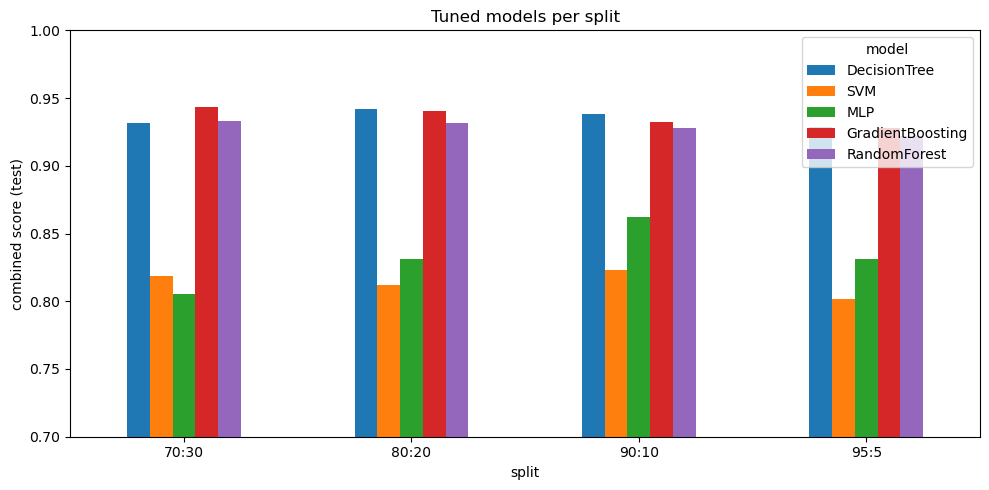

In [10]:
# 15. Model Comparison of the tuned models (no feature selection)
model_order = ["DecisionTree", "SVM", "MLP", "GradientBoosting", "RandomForest"]
search_df = pd.DataFrame(search_results)
show_cols = ["model", "params", "cv_score", "accuracy", "f1", "precision", "recall", "roc_auc", "combined_score"]

for test_size in split_ratios:
    split_tag = f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}"
    sub = search_df[search_df["test_size"] == test_size].sort_values("combined_score", ascending=False)
    print(f"\n{'#' * 20} Split {split_tag} {'#' * 20}")
    print(f"===== Best per model (ranked by test combined accuracy + f1 + roc_auc score) - Split {split_tag} =====")
    print(sub[show_cols].to_string(index=False))
    top = sub.iloc[0]
    print(f"\n===== Best model: {top['model']} {top['params']} =====")
    print_metrics(top["model"], top)

best_all = search_df.loc[search_df["combined_score"].idxmax()]
print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: {best_all['model']} {best_all['params']}, "
    f"split={int(round((1 - best_all['test_size']) * 100))}:{int(round(best_all['test_size'] * 100))} ====="
)
print_metrics(best_all["model"], best_all)

print(f"\n{'#' * 20} MEAN OVER SPLITS {'#' * 20}")
print(search_df.groupby("model")[["accuracy", "f1", "precision", "recall", "roc_auc", "combined_score"]].mean()
      .loc[model_order].sort_values("combined_score", ascending=False).round(4).to_string())

pv = search_df.pivot(index="test_size", columns="model", values="combined_score")[model_order].loc[split_ratios]
ax = pv.plot(kind="bar", figsize=(10, 5), ylim=(0.7, 1.0), rot=0)
ax.set_xticklabels([f"{int(round((1 - t) * 100))}:{int(round(t * 100))}" for t in pv.index])
ax.set_xlabel("split")
ax.set_ylabel("combined score (test)")
ax.set_title("Tuned models per split")
plt.tight_layout()
plt.show()


# 16. Tuned Models + ANOVA (SelectKBest f_classif) — scale before vs after feature selection

In [11]:
# 16. Tuned models + ANOVA (SelectKBest f_classif), scale before vs after feature selection
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import pandas as pd

# needs the setup cell (section 9) and the model cells (sections 10-14) to have run: BEST_PARAMS, X, Y, helpers
k_list = [5, 10, 15, 20, 25, 30, X.shape[1]]  # number of features kept (last = all features = no selection)
scale_orders = ["scale_before", "scale_after"]  # scale -> select features   vs   select features -> scale
n_features = X.shape[1]
model_names = ["DecisionTree", "SVM", "MLP", "GradientBoosting", "RandomForest"]
# hyper-parameters: BEST_PARAMS[split][model], found by the searches in sections 10-14


def rank_features(X_fit, y_fit):
    """Return column indices ordered from best to worst ANOVA F-score (fit on the training set only)."""
    f_scores = SelectKBest(f_classif, k="all").fit(X_fit, y_fit).scores_
    return np.argsort(-np.where(np.isnan(f_scores), -np.inf, f_scores), kind="mergesort")

FS_NAME = "ANOVA"
all_results = []  # every run of every split, to find the best model overall

for test_size in split_ratios:
    split_tag = f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}"
    print(f"\n{'#' * 20} Split {split_tag} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=0, stratify=Y
    )
    split_results = []
    cache = {}  # (model, selected columns) -> metrics; the same subset gives the same scaled data in both orders

    for scale_order in scale_orders:
        # --- feature ranking (depends on the scaling order) and scaled data for every k ---
        if scale_order == "scale_before":
            scaler = StandardScaler().fit(X_train)
            ranking = rank_features(scaler.transform(X_train), y_train)
            X_train_all, X_test_all = scaler.transform(X_train), scaler.transform(X_test)
        else:
            ranking = rank_features(X_train.values, y_train)

        data = {}
        for k in k_list:
            cols = sorted(ranking[:k])
            if scale_order == "scale_before":
                data[k] = (cols, X_train_all[:, cols], X_test_all[:, cols])
            else:
                sc = StandardScaler().fit(X_train.iloc[:, cols])
                data[k] = (cols, sc.transform(X_train.iloc[:, cols]), sc.transform(X_test.iloc[:, cols]))

        # --- train every model on every feature subset ---
        for name in model_names:
            params = BEST_PARAMS[test_size][name]
            print(f"\n===== {name} + {FS_NAME} ({scale_order}): {params}, changing num of features =====")
            for k in k_list:
                cols, Xtr, Xte = data[k]
                key = (name, tuple(cols))
                if key not in cache:
                    model = build_model(name, params).fit(Xtr, y_train)
                    cache[key] = compute_metrics(y_test, model.predict(Xte), get_score(model, Xte))
                m = cache[key]
                print_metrics(f"k={k}", m)
                split_results.append({
                    "fs": FS_NAME, "scale_order": scale_order, "model": name, "k": k,
                    "params": str(params), "features": ", ".join(X.columns[cols]), **m,
                })

    results_df = pd.DataFrame(split_results)

    show_cols = ["scale_order", "model", "k", "accuracy", "f1", "precision", "recall", "roc_auc", "combined_score"]
    best_per_model = (
        results_df.loc[results_df.groupby(["scale_order", "model"])["combined_score"].idxmax()]
        .sort_values(["scale_order", "combined_score"], ascending=[False, False], kind="mergesort")
    )
    print(f"\n===== Best per model ({FS_NAME}, ranked by combined accuracy + f1 + roc_auc score) - Split {split_tag} =====")
    print(best_per_model[show_cols].to_string(index=False))

    best_row = results_df.loc[results_df["combined_score"].idxmax()]
    print(f"\n===== Best model: {best_row['model']} + {FS_NAME} ({best_row['scale_order']}), k={best_row['k']} =====")
    print_metrics(f"{best_row['model']}, k={best_row['k']}", best_row)
    print(f"Selected features: {best_row['features']}")

    results_df["test_size"] = test_size
    all_results.append(results_df)

anova_all_results_df = pd.concat(all_results, ignore_index=True)
best_overall = anova_all_results_df.loc[anova_all_results_df["combined_score"].idxmax()]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS ({FS_NAME}) {'#' * 20}")
print(
    f"===== Best model: {best_overall['model']} ({best_overall['scale_order']}), k={best_overall['k']}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print_metrics(f"{best_overall['model']}, k={best_overall['k']}", best_overall)



#################### Split 70:30 ####################

===== DecisionTree + ANOVA (scale_before): {'criterion': 'log_loss', 'max_depth': 5}, changing num of features =====
k=5                                      acc=0.9504  f1=0.9286  precision=0.9455  recall=0.9123  roc_auc=0.9386  combined=0.9392
k=10                                     acc=0.9457  f1=0.9227  precision=0.9289  recall=0.9167  roc_auc=0.9432  combined=0.9372
k=15                                     acc=0.9442  f1=0.9196  precision=0.9364  recall=0.9035  roc_auc=0.9316  combined=0.9318
k=20                                     acc=0.9442  f1=0.9196  precision=0.9364  recall=0.9035  roc_auc=0.9316  combined=0.9318
k=25                                     acc=0.9426  f1=0.9187  precision=0.9207  recall=0.9167  roc_auc=0.9451  combined=0.9355
k=30                                     acc=0.9380  f1=0.9127  precision=0.9087  recall=0.9167  roc_auc=0.9436  combined=0.9314
k=32                                     acc=0.9380  

# 17. Tuned Models + RFE (Recursive Feature Elimination) — scale before vs after feature selection

In [12]:
# 17. Tuned models + RFE (Recursive Feature Elimination), scale before vs after feature selection
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# needs the setup cell (section 9) and the model cells (sections 10-14) to have run: BEST_PARAMS, X, Y, helpers
k_list = [5, 10, 15, 20, 25, 30, X.shape[1]]  # number of features kept (last = all features = no selection)
# RFE needs an estimator that exposes coef_ / feature_importances_ (SVC rbf and MLP do not), so a
# logistic regression ranks the features for every model. Its coefficients depend on the feature scale,
# which is what makes 'scale before' and 'scale after' selection different.
rfe_estimator = LogisticRegression(max_iter=2000)
scale_orders = ["scale_before", "scale_after"]  # scale -> select features   vs   select features -> scale
n_features = X.shape[1]
model_names = ["DecisionTree", "SVM", "MLP", "GradientBoosting", "RandomForest"]
# hyper-parameters: BEST_PARAMS[split][model], found by the searches in sections 10-14


def rank_features(X_fit, y_fit):
    """Return column indices ordered from best to worst RFE rank (fit on the training set only).
    Eliminating one feature at a time down to 1 gives the full ranking once; the top-k is then the
    same subset RFE(n_features_to_select=k) would keep."""
    rfe = RFE(rfe_estimator, n_features_to_select=1, step=1).fit(X_fit, y_fit)
    return np.argsort(rfe.ranking_, kind="mergesort")

FS_NAME = "RFE"
all_results = []  # every run of every split, to find the best model overall

for test_size in split_ratios:
    split_tag = f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}"
    print(f"\n{'#' * 20} Split {split_tag} {'#' * 20}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=0, stratify=Y
    )
    split_results = []
    cache = {}  # (model, selected columns) -> metrics; the same subset gives the same scaled data in both orders

    for scale_order in scale_orders:
        # --- feature ranking (depends on the scaling order) and scaled data for every k ---
        if scale_order == "scale_before":
            scaler = StandardScaler().fit(X_train)
            ranking = rank_features(scaler.transform(X_train), y_train)
            X_train_all, X_test_all = scaler.transform(X_train), scaler.transform(X_test)
        else:
            ranking = rank_features(X_train.values, y_train)

        data = {}
        for k in k_list:
            cols = sorted(ranking[:k])
            if scale_order == "scale_before":
                data[k] = (cols, X_train_all[:, cols], X_test_all[:, cols])
            else:
                sc = StandardScaler().fit(X_train.iloc[:, cols])
                data[k] = (cols, sc.transform(X_train.iloc[:, cols]), sc.transform(X_test.iloc[:, cols]))

        # --- train every model on every feature subset ---
        for name in model_names:
            params = BEST_PARAMS[test_size][name]
            print(f"\n===== {name} + {FS_NAME} ({scale_order}): {params}, changing num of features =====")
            for k in k_list:
                cols, Xtr, Xte = data[k]
                key = (name, tuple(cols))
                if key not in cache:
                    model = build_model(name, params).fit(Xtr, y_train)
                    cache[key] = compute_metrics(y_test, model.predict(Xte), get_score(model, Xte))
                m = cache[key]
                print_metrics(f"k={k}", m)
                split_results.append({
                    "fs": FS_NAME, "scale_order": scale_order, "model": name, "k": k,
                    "params": str(params), "features": ", ".join(X.columns[cols]), **m,
                })

    results_df = pd.DataFrame(split_results)

    show_cols = ["scale_order", "model", "k", "accuracy", "f1", "precision", "recall", "roc_auc", "combined_score"]
    best_per_model = (
        results_df.loc[results_df.groupby(["scale_order", "model"])["combined_score"].idxmax()]
        .sort_values(["scale_order", "combined_score"], ascending=[False, False], kind="mergesort")
    )
    print(f"\n===== Best per model ({FS_NAME}, ranked by combined accuracy + f1 + roc_auc score) - Split {split_tag} =====")
    print(best_per_model[show_cols].to_string(index=False))

    best_row = results_df.loc[results_df["combined_score"].idxmax()]
    print(f"\n===== Best model: {best_row['model']} + {FS_NAME} ({best_row['scale_order']}), k={best_row['k']} =====")
    print_metrics(f"{best_row['model']}, k={best_row['k']}", best_row)
    print(f"Selected features: {best_row['features']}")

    results_df["test_size"] = test_size
    all_results.append(results_df)

rfe_all_results_df = pd.concat(all_results, ignore_index=True)
best_overall = rfe_all_results_df.loc[rfe_all_results_df["combined_score"].idxmax()]
best_split = best_overall["test_size"]

print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS ({FS_NAME}) {'#' * 20}")
print(
    f"===== Best model: {best_overall['model']} ({best_overall['scale_order']}), k={best_overall['k']}, "
    f"split={int(round((1 - best_split) * 100))}:{int(round(best_split * 100))} ====="
)
print_metrics(f"{best_overall['model']}, k={best_overall['k']}", best_overall)



#################### Split 70:30 ####################

===== DecisionTree + RFE (scale_before): {'criterion': 'log_loss', 'max_depth': 5}, changing num of features =====
k=5                                      acc=0.9504  f1=0.9286  precision=0.9455  recall=0.9123  roc_auc=0.9386  combined=0.9392
k=10                                     acc=0.9442  f1=0.9196  precision=0.9364  recall=0.9035  roc_auc=0.9480  combined=0.9373
k=15                                     acc=0.9457  f1=0.9217  precision=0.9406  recall=0.9035  roc_auc=0.9360  combined=0.9345
k=20                                     acc=0.9442  f1=0.9204  precision=0.9286  recall=0.9123  roc_auc=0.9431  combined=0.9359
k=25                                     acc=0.9333  f1=0.9059  precision=0.9039  recall=0.9079  roc_auc=0.9379  combined=0.9257
k=30                                     acc=0.9395  f1=0.9147  precision=0.9127  recall=0.9167  roc_auc=0.9455  combined=0.9332
k=32                                     acc=0.9380  f1

# 18. Model Comparison: No Feature Selection vs ANOVA vs RFE


#################### Split 70:30 ####################

===== Combined score (accuracy + f1 + roc_auc) / 3: model x method =====
method             No FS  ANOVA | scale before  ANOVA | scale after  RFE | scale before  RFE | scale after
model                                                                                                     
DecisionTree      0.9314                0.9392               0.9392              0.9392             0.9425
SVM               0.8186                0.8196               0.8196              0.8202             0.8260
MLP               0.8056                0.8957               0.8957              0.8957             0.8677
GradientBoosting  0.9432                0.9432               0.9432              0.9448             0.9431
RandomForest      0.9329                0.9444               0.9444              0.9444             0.9423

===== Best k: model x method =====
method            No FS  ANOVA | scale before  ANOVA | scale after  RFE | scale before

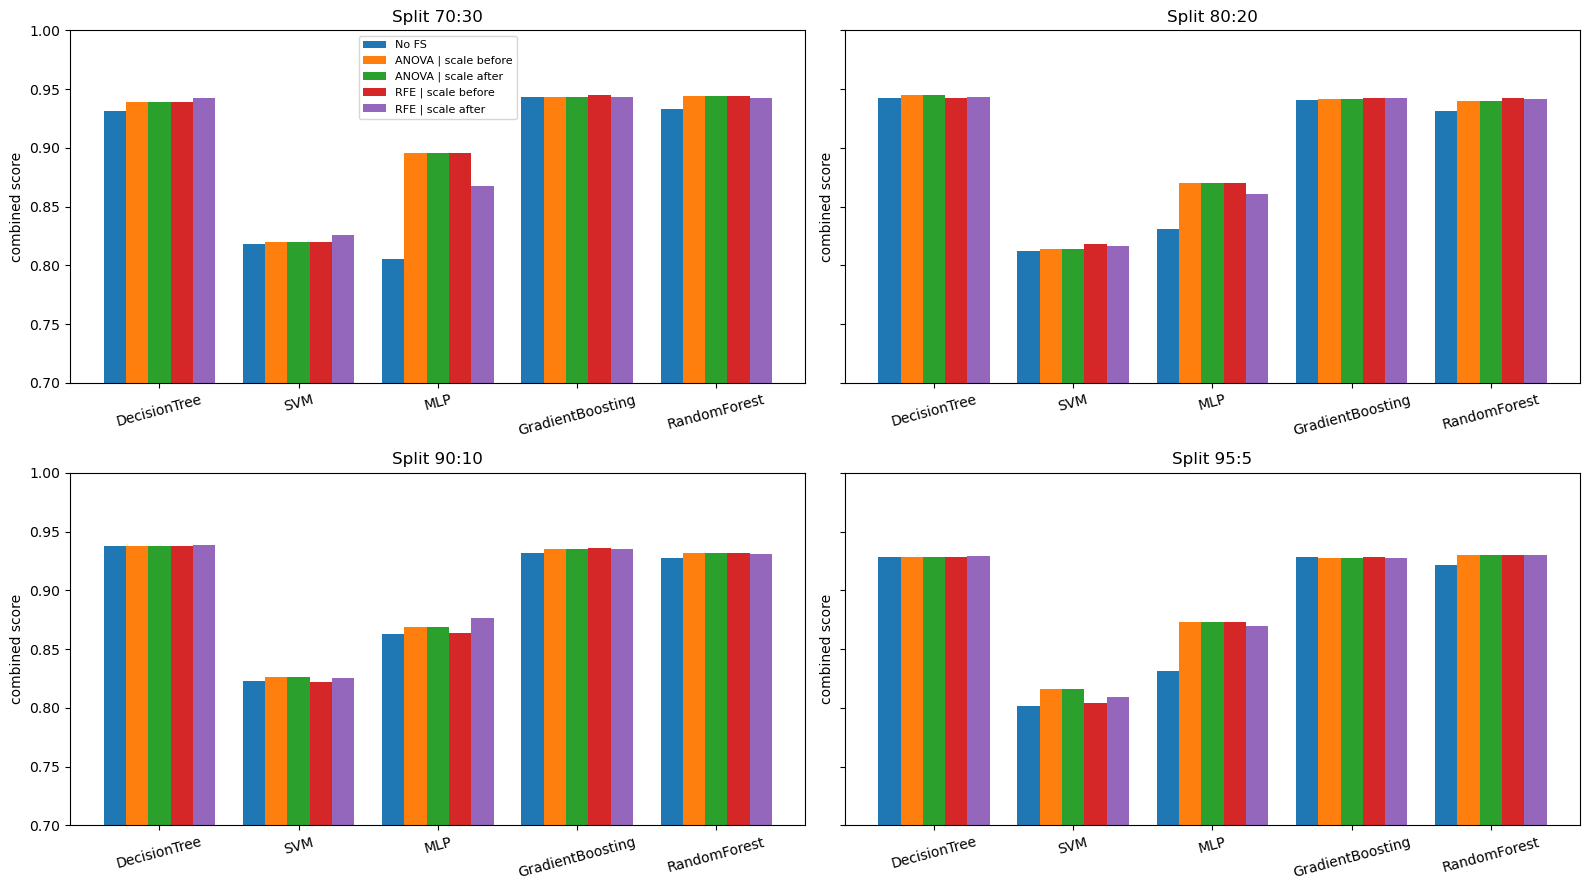

In [13]:
# 18. Model Comparison: No feature selection vs ANOVA vs RFE (scale before / after)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# needs anova_all_results_df (section 16) and rfe_all_results_df (section 17) from the cells above
n_features = X.shape[1]
method_order = ["No FS", "ANOVA | scale before", "ANOVA | scale after", "RFE | scale before", "RFE | scale after"]
model_order = ["DecisionTree", "SVM", "MLP", "GradientBoosting", "RandomForest"]

# "No FS" = every feature kept (k = all). Scaling order is irrelevant there, so one copy is enough.
no_fs = anova_all_results_df[
    (anova_all_results_df["k"] == n_features) & (anova_all_results_df["scale_order"] == "scale_before")
].copy()
no_fs["method"] = "No FS"

# real feature selection only (k < all), so a method cannot win just by keeping everything
fs_rows = pd.concat([anova_all_results_df, rfe_all_results_df], ignore_index=True)
fs_rows = fs_rows[fs_rows["k"] < n_features].copy()
fs_rows["method"] = fs_rows["fs"] + " | " + fs_rows["scale_order"].str.replace("_", " ")

combined = pd.concat([no_fs, fs_rows], ignore_index=True)
combined["method"] = pd.Categorical(combined["method"], method_order, ordered=True)
combined["model"] = pd.Categorical(combined["model"], model_order, ordered=True)

# best k for every (split, model, method); idxmax keeps the smallest k on ties
best = combined.loc[combined.groupby(["test_size", "model", "method"], observed=True)["combined_score"].idxmax()]
show_cols = ["model", "method", "k", "accuracy", "f1", "precision", "recall", "roc_auc", "combined_score"]

summary = []
for test_size in sorted(best["test_size"].unique(), reverse=True):
    split_tag = f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}"
    sub = best[best["test_size"] == test_size]
    print(f"\n{'#' * 20} Split {split_tag} {'#' * 20}")

    print("\n===== Combined score (accuracy + f1 + roc_auc) / 3: model x method =====")
    print(sub.pivot(index="model", columns="method", values="combined_score").round(4).to_string())
    print("\n===== Best k: model x method =====")
    print(sub.pivot(index="model", columns="method", values="k").to_string())

    print(f"\n===== Best per model - Split {split_tag} =====")
    best_per_model = sub.loc[sub.groupby("model", observed=True)["combined_score"].idxmax()]
    print(best_per_model.sort_values("combined_score", ascending=False)[show_cols].to_string(index=False))

    top = sub.loc[sub["combined_score"].idxmax()]
    print(f"\n===== Best model: {top['model']} + {top['method']}, k={top['k']} =====")
    print(
        f"acc={top['accuracy']:.4f}  f1={top['f1']:.4f}  precision={top['precision']:.4f}  "
        f"recall={top['recall']:.4f}  roc_auc={top['roc_auc']:.4f}  combined_score={top['combined_score']:.4f}"
    )
    print(f"Selected features: {top['features']}")
    summary.append(top)

best_all = max(summary, key=lambda r: r["combined_score"])
print(f"\n{'#' * 20} BEST MODEL ACROSS ALL SPLITS {'#' * 20}")
print(
    f"===== Best model: {best_all['model']} + {best_all['method']}, k={best_all['k']}, "
    f"split={int(round((1 - best_all['test_size']) * 100))}:{int(round(best_all['test_size'] * 100))} ====="
)
print(
    f"acc={best_all['accuracy']:.4f}  f1={best_all['f1']:.4f}  precision={best_all['precision']:.4f}  "
    f"recall={best_all['recall']:.4f}  roc_auc={best_all['roc_auc']:.4f}  combined_score={best_all['combined_score']:.4f}"
)

print(f"\n{'#' * 20} MEAN OVER SPLITS: combined score, model x method {'#' * 20}")
print(best.pivot_table(index="model", columns="method", values="combined_score", observed=True).round(4).to_string())

# grouped bars: best combined score per model, one panel per split
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
width = 0.16
for ax, test_size in zip(axes.ravel(), sorted(best["test_size"].unique(), reverse=True)):
    pv = best[best["test_size"] == test_size].pivot(index="model", columns="method", values="combined_score")
    for i, method in enumerate(method_order):
        ax.bar(np.arange(len(model_order)) + (i - 2) * width, pv.loc[model_order, method], width, label=method)
    ax.set_xticks(np.arange(len(model_order)))
    ax.set_xticklabels(model_order, rotation=15)
    ax.set_ylim(0.7, 1.0)
    ax.set_title(f"Split {int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}")
    ax.set_ylabel("combined score")d
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()
